# ALIA — Data Acquisition & Understanding (BO2/DSO2)

**Business Objective (BO2):** Support medical representatives in delivering clear and multilingual medical presentations during real interactions.  
**Data Science Objective (DSO2):** Use a RAG-based LLM system to generate compliant medical answers.

This notebook focuses on **data loading, profiling, and visualization** for all datasets used in BO2/DSO2:

1. **CRM Pharma Dataset** (`crm_dataset.json`) — CRM entities (users/products/visits/prospects…).  
2. **Conversation / Visits Dataset** (`vital_bo6_datasetProduit.json`) — multilingual transcripts + objections + scores.  
3. **Vital Product Knowledge** (derived from the conversation dataset fields: product_name/category/description).  
4. **FDA Large Dataset** (`fda_large_dataset.csv`) — compliance/reference dataset.

---

## 0) Setup
We keep visualizations simple and readable using **matplotlib** (no seaborn), and we write robust code that adapts to missing columns/fields.

In [2]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

DATA = Path("/content")
CRM_PATH = DATA / "crm_dataset.json"
CONV_PATH = DATA / "vital_bo6_datasetProduit.json"
FDA_PATH = DATA / "fda_large_dataset.csv"

assert CRM_PATH.exists(), f"Missing file: {CRM_PATH}"
assert CONV_PATH.exists(), f"Missing file: {CONV_PATH}"
assert FDA_PATH.exists(), f"Missing file: {FDA_PATH}"

print("Files found:")
print(" -", CRM_PATH)
print(" -", CONV_PATH)
print(" -", FDA_PATH)

Files found:
 - /content/crm_dataset.json
 - /content/vital_bo6_datasetProduit.json
 - /content/fda_large_dataset.csv


## Helper Functions
Small utilities to make EDA easier (safe column checks, plotting helpers).

In [3]:
def safe_value_counts(df: pd.DataFrame, col: str, topn: int = 15) -> pd.Series:
    if col not in df.columns:
        return pd.Series(dtype=int)
    return df[col].astype("string").fillna("NA").value_counts().head(topn)

def plot_bar(series: pd.Series, title: str, xlabel: str = "", ylabel: str = "Count", rotate: int = 45):
    if series is None or len(series) == 0:
        print(f"[Skip] Nothing to plot for: {title}")
        return
    ax = series.sort_values(ascending=False).plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.show()

def plot_hist(values, title: str, xlabel: str = "", bins: int = 30):
    values = pd.Series(values).dropna()
    if len(values) == 0:
        print(f"[Skip] Nothing to plot for: {title}")
        return
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

def plot_scatter(x, y, title: str, xlabel: str, ylabel: str):
    x = pd.Series(x)
    y = pd.Series(y)
    mask = x.notna() & y.notna()
    if mask.sum() == 0:
        print(f"[Skip] Nothing to plot for: {title}")
        return
    plt.scatter(x[mask], y[mask])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def missingness_bar(df: pd.DataFrame, title: str, topn: int = 30):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0].head(topn)
    plot_bar((miss * 100).round(2), title=title, xlabel="Columns", ylabel="Missing %", rotate=75)

# 1) CRM Pharma Dataset (`crm_dataset.json`)
This dataset is **relational** in JSON form. It typically contains:
- `metadata`: dataset description and counts per table
- `lookup_tables`: small dimension tables (specialties, regions, user types…)
- `data`: main tables (users, products, prospects, visits…)

We will:
1. Load the JSON.
2. Inspect available tables and sizes.
3. Convert key tables to pandas DataFrames.
4. Visualize core distributions (users/products/visits if available).

In [4]:
with open(CRM_PATH, "r", encoding="utf-8") as f:
    crm = json.load(f)

crm.keys()

dict_keys(['metadata', 'lookup_tables', 'data'])

CRM metadata (high level):


,0
generated_at,2026-02-23T16:56:14.212824
description,Dataset CRM Pharma - données synthétiques pour projet IA
version,1.0
tables,"{'user_types': 3, 'users': 20, 'specialites': 8, 'gouvernerats': 8, 'delegations': 10, 'activites': 4, 'potentiels': 3, 'etablissements': 5, 'type_visites': 4, 'aires': 5, 'prod_categories': 5, 'z..."



Table sizes (from metadata):


,rows
visite_products,504
visites,200
affectations,158
prog_visites,100
prospects,80
objectifs_gro_bu,60
demandes,50
commentaires,40
prdspecs,33
products,30


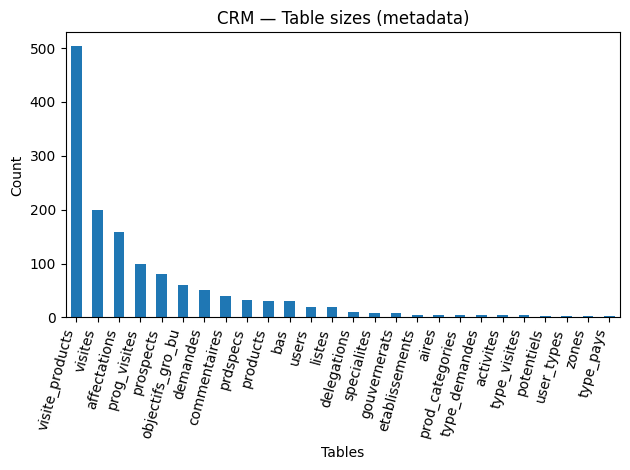

In [5]:
crm_metadata = crm.get("metadata", {})
crm_tables = (crm_metadata.get("tables") or {})
crm_tables = pd.Series(crm_tables).sort_values(ascending=False)

print("CRM metadata (high level):")
display(pd.DataFrame([crm_metadata]).T)

print("\nTable sizes (from metadata):")
display(crm_tables.to_frame("rows"))
plot_bar(crm_tables, title="CRM — Table sizes (metadata)", xlabel="Tables", rotate=75)

CRM metadata (high level):


,field,value
0,generated_at,2026-02-23T16:56:14.212824
1,description,Dataset CRM Pharma - données synthétiques pour projet IA
2,version,1.0



Table sizes (from metadata):


,rows
visite_products,504
visites,200
affectations,158
prog_visites,100
prospects,80
objectifs_gro_bu,60
demandes,50
commentaires,40
prdspecs,33
products,30


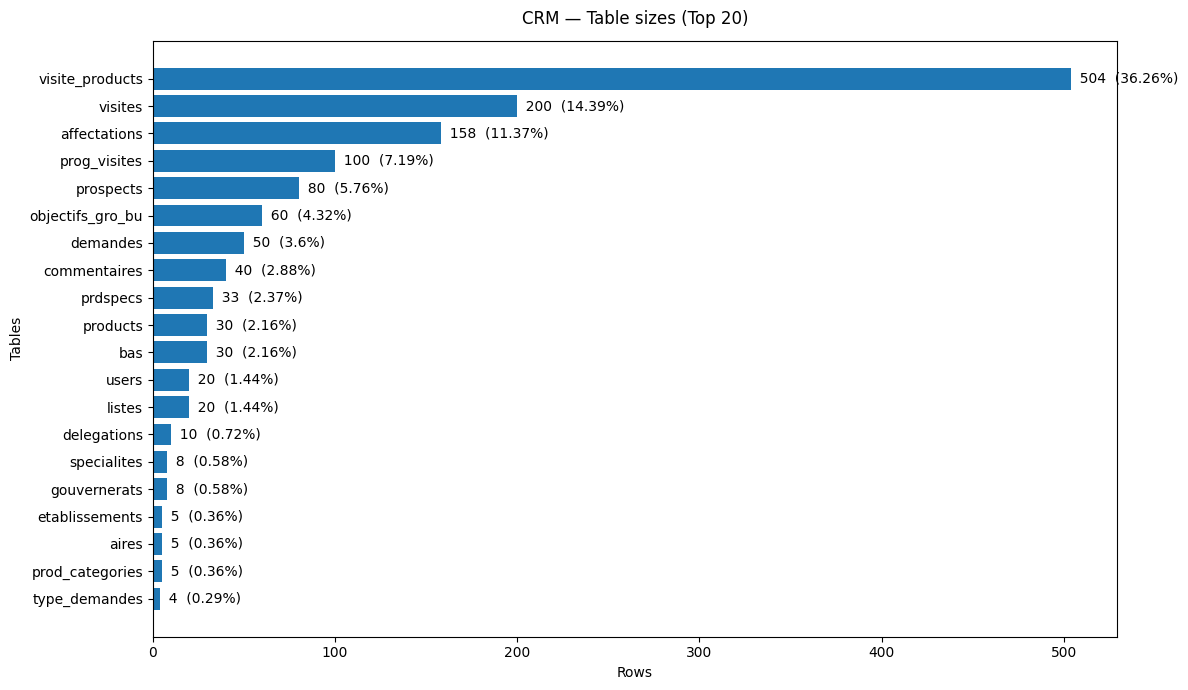

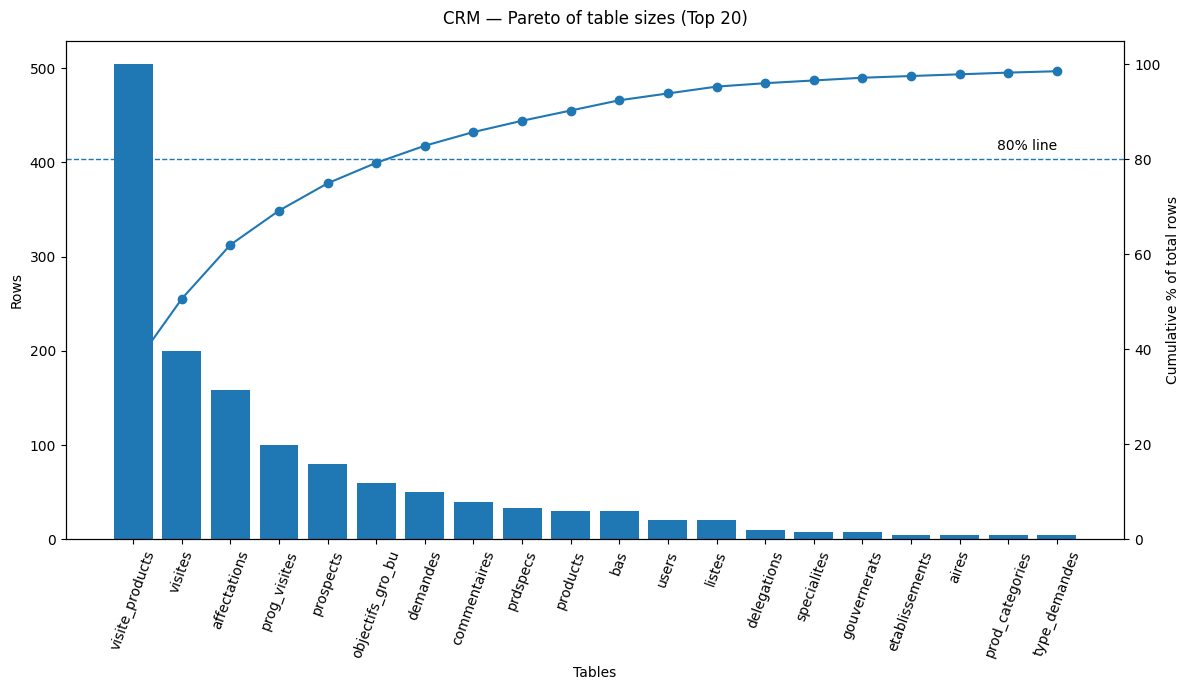


Key insight:
- Total rows across tables: 1390
- Top 3 tables: visite_products, visites, affectations = 862 rows (62.0% of total)


In [6]:
#amelioration
import pandas as pd
import matplotlib.pyplot as plt

# --- Extract metadata + table sizes ---
crm_metadata = crm.get("metadata", {}) or {}
tables_dict = crm_metadata.get("tables") or {}

crm_tables = (
    pd.Series(tables_dict, name="rows")
    .sort_values(ascending=False)
    .astype(int)
)

# --- 1) Nice metadata display (without the huge dict inside) ---
meta_clean = {k: v for k, v in crm_metadata.items() if k != "tables"}
meta_df = pd.DataFrame(meta_clean.items(), columns=["field", "value"])

print("CRM metadata (high level):")
display(meta_df)

print("\nTable sizes (from metadata):")
display(crm_tables.to_frame())

# --- 2) Better visualization: Horizontal bar + % of total + labels ---
total_rows = crm_tables.sum()
df_sizes = crm_tables.reset_index()
df_sizes.columns = ["table", "rows"]
df_sizes["pct_total"] = (df_sizes["rows"] / total_rows * 100).round(2)

# Optional: show only Top N to keep it readable
TOP_N = 20
df_plot = df_sizes.head(TOP_N).copy()

plt.figure(figsize=(12, 7))
bars = plt.barh(df_plot["table"][::-1], df_plot["rows"][::-1])  # reverse for biggest on top

plt.title(f"CRM — Table sizes (Top {TOP_N})", pad=12)
plt.xlabel("Rows")
plt.ylabel("Tables")

# Annotate bars with rows + %
for i, (rows, pct) in enumerate(zip(df_plot["rows"][::-1], df_plot["pct_total"][::-1])):
    plt.text(rows, i, f"  {rows}  ({pct}%)", va="center")

plt.tight_layout()
plt.show()

# --- 3) Pareto chart: bars + cumulative % line ---
df_pareto = df_sizes.copy()
df_pareto["cum_pct"] = (df_pareto["rows"].cumsum() / total_rows * 100)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.bar(df_pareto["table"].head(TOP_N), df_pareto["rows"].head(TOP_N))
ax1.set_title(f"CRM — Pareto of table sizes (Top {TOP_N})", pad=12)
ax1.set_xlabel("Tables")
ax1.set_ylabel("Rows")
ax1.tick_params(axis="x", rotation=70)

ax2 = ax1.twinx()
ax2.plot(df_pareto["table"].head(TOP_N), df_pareto["cum_pct"].head(TOP_N), marker="o")
ax2.set_ylabel("Cumulative % of total rows")
ax2.set_ylim(0, 105)

# Add a 80% reference line
ax2.axhline(80, linestyle="--", linewidth=1)
ax2.text(TOP_N - 1, 82, "80% line", ha="right")

fig.tight_layout()
plt.show()

# --- Quick textual insight (non-vague) ---
top3 = df_sizes.head(3)
print("\nKey insight:")
print(f"- Total rows across tables: {total_rows}")
print(f"- Top 3 tables: {', '.join(top3['table'])} = {top3['rows'].sum()} rows "
      f"({(top3['rows'].sum()/total_rows*100):.1f}% of total)")

## 1.1 Load CRM Tables to DataFrames
We convert every table in `crm['data']` into a DataFrame and keep them in a dictionary.

In [7]:
crm_data = crm.get("data", {})
crm_dfs = {}

for table_name, rows in crm_data.items():
    # Some tables may be missing or not in list format
    if isinstance(rows, list):
        crm_dfs[table_name] = pd.DataFrame(rows)
    else:
        # fallback: store as single-row dataframe if possible
        crm_dfs[table_name] = pd.DataFrame([rows])

print("Loaded CRM tables:", list(crm_dfs.keys()))
{t: df.shape for t, df in crm_dfs.items()}

Loaded CRM tables: ['users', 'products', 'prospects', 'affectations', 'visites', 'visite_products', 'demandes', 'bas', 'prog_visites', 'commentaires', 'objectifs_gro_bu', 'prdspecs', 'listes']


{'users': (20, 13),
 'products': (30, 7),
 'prospects': (80, 12),
 'affectations': (158, 3),
 'visites': (200, 7),
 'visite_products': (504, 3),
 'demandes': (50, 6),
 'bas': (30, 8),
 'prog_visites': (100, 5),
 'commentaires': (40, 4),
 'objectifs_gro_bu': (60, 5),
 'prdspecs': (33, 3),
 'listes': (20, 5)}

## 1.2 Quick Preview: Users & Products
These two tables are usually the most important to connect real interactions with product knowledge.

In [9]:
users = crm_dfs.get("users", pd.DataFrame())
products = crm_dfs.get("products", pd.DataFrame())

display(users.head(5))
display(products.head(5))

print("users shape:", users.shape)
print("products shape:", products.shape)

,id,login,password,Nom,Prenom,Email,Tel,type,role,sup,zone,zone2,actif
0,1,user01,hashed_pwd_1,Mejri,Sonia,user1@pharmacrm.tn,+216 48 242 854,1,user,16.0,1,NaN,True
1,2,user02,hashed_pwd_2,Bouzid,Ahmed,user2@pharmacrm.tn,+216 23 195 323,1,user,16.0,3,NaN,True
2,3,user03,hashed_pwd_3,Hamdi,Rami,user3@pharmacrm.tn,+216 73 325 559,1,user,16.0,3,3.0,True
3,4,user04,hashed_pwd_4,Bouzid,Leila,user4@pharmacrm.tn,+216 55 259 320,1,user,16.0,1,1.0,True
4,5,user05,hashed_pwd_5,Trabelsi,Youssef,user5@pharmacrm.tn,+216 32 467 967,1,user,18.0,1,NaN,True


,id,code_article,name,gamme_id,aire,prix,actif
0,1,PRD0001,Cardioplus 5mg,2,5,143.26,True
1,2,PRD0002,Cardioplus 10mg,5,1,91.85,True
2,3,PRD0003,Amoxicare 500mg,4,1,21.22,True
3,4,PRD0004,Amoxicare 1g,3,3,39.72,True
4,5,PRD0005,Doliphar 500mg,2,5,142.31,True


users shape: (20, 13)
products shape: (30, 7)


## 1.3 Users — Role/Type/Zone Distributions
We visualize:
- distribution by `role` and/or `type`
- distribution by `zone`
- active vs inactive ratio

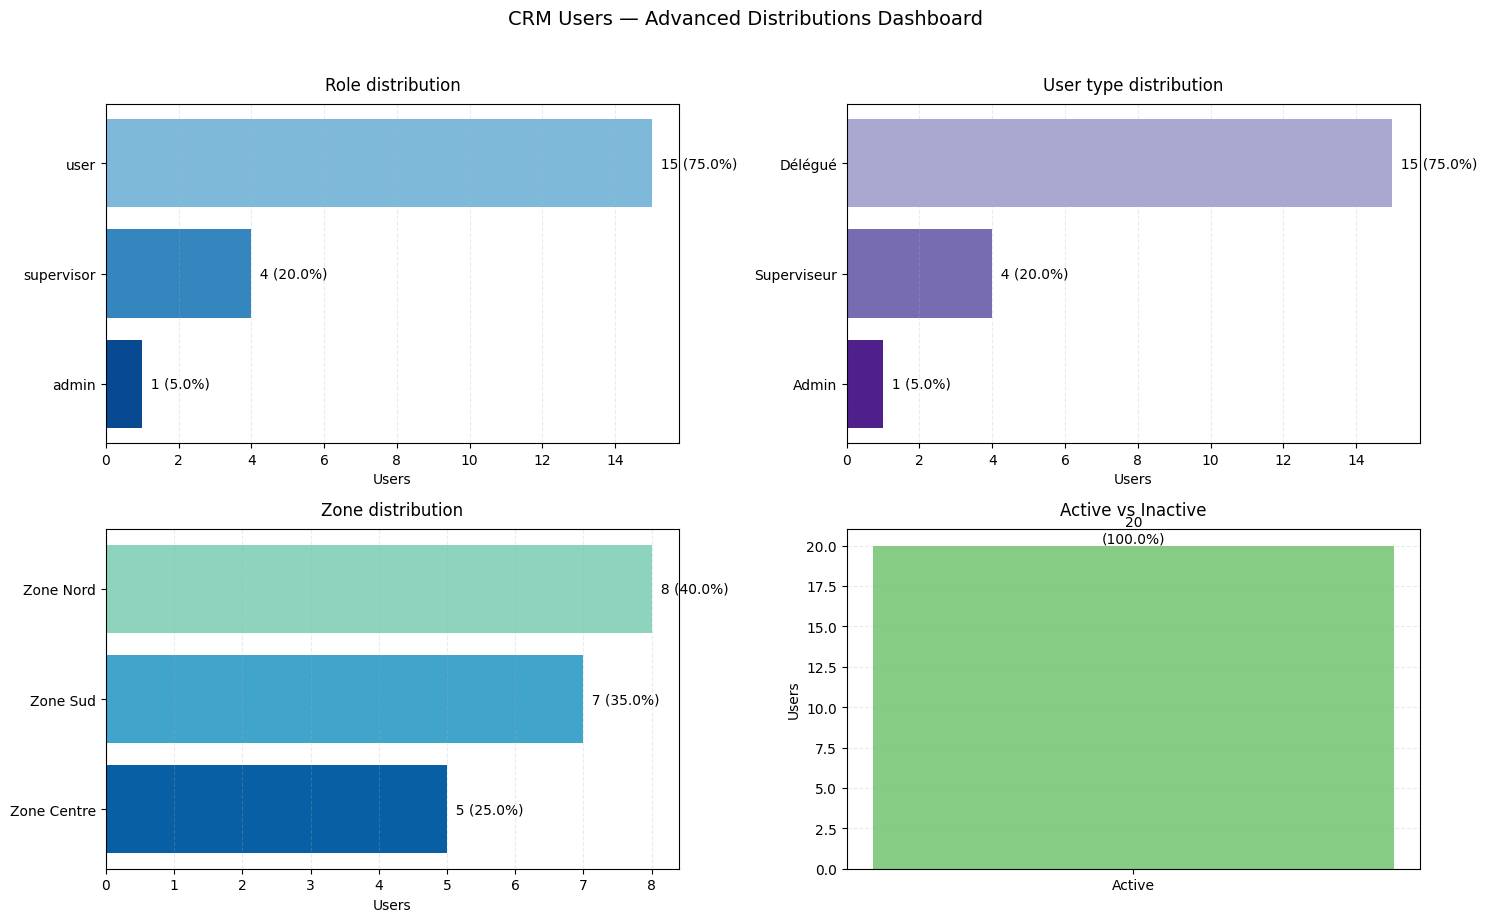


Insights (Users):
- Total users: 20
- Main role: user (15/20)
- User-to-supervisor ratio: 3.75:1
- Top zone: Zone Nord (8/20)
- Active users: 100.0%


In [24]:
# --- BO2: CRM Users — Advanced Distributions (labels + nicer dashboard) ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

def barh_with_pct(ax, series, title, xlabel="Count", cmap="Blues"):
    """Pretty horizontal bar chart with count + % labels."""
    series = series.copy()
    series = series[series.index.notna()]
    total = series.sum()

    labels = series.index.astype(str)
    values = series.values

    colors = getattr(plt.cm, cmap)(np.linspace(0.45, 0.9, len(series)))
    ax.barh(labels, values, color=colors)

    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.invert_yaxis()

    for i, v in enumerate(values):
        pct = (v / total * 100) if total else 0
        ax.text(v, i, f"  {v} ({pct:.1f}%)", va="center")

def build_lookup_map(lookup_list, id_key="id", label_keys=("libelle","label","name","nom","titre","designation")):
    """Build {id: label} from lookup_tables list of dicts."""
    if not isinstance(lookup_list, list):
        return {}
    m = {}
    for d in lookup_list:
        if not isinstance(d, dict) or id_key not in d:
            continue
        lab = None
        for k in label_keys:
            if k in d and pd.notna(d[k]):
                lab = d[k]
                break
        m[d[id_key]] = lab if lab else f"{id_key}={d[id_key]}"
    return m

# ---- Ensure users exist ----
if "users" not in globals() or users is None:
    users = crm_dfs.get("users", pd.DataFrame())

if users is None or users.empty:
    print("Users table not found or empty.")
else:
    # ---- Load lookup_tables from the CRM JSON (to replace 1/2/3 with real labels) ----
    CRM_PATH = Path("crm_dataset.json")  # same folder as notebook in Colab
    if not CRM_PATH.exists():
        # fallback: try /mnt/data (ChatGPT sandbox) and Colab root
        for p in [Path("/mnt/data/crm_dataset.json"), Path("./crm_dataset.json")]:
            if p.exists():
                CRM_PATH = p
                break

    lookup_tables = {}
    if CRM_PATH.exists():
        with open(CRM_PATH, "r", encoding="utf-8") as f:
            crm_json = json.load(f)
        lookup_tables = crm_json.get("lookup_tables", {}) or {}

    # ---- Maps (best effort): user types & zones ----
    user_type_map = build_lookup_map(lookup_tables.get("user_types", []))
    zone_map = build_lookup_map(lookup_tables.get("zones", []))

    u = users.copy()

    # ---- Human-friendly columns ----
    # Type labels (avoid 1/2/3)
    if "type" in u.columns:
        u["_type_label"] = pd.to_numeric(u["type"], errors="coerce").map(user_type_map)
        u["_type_label"] = u["_type_label"].fillna(u["type"].apply(lambda x: f"Type {x}" if pd.notna(x) else "NA"))
    else:
        u["_type_label"] = "NA"

    # Zone labels (avoid 1/2/3)
    if "zone" in u.columns:
        u["_zone_label"] = pd.to_numeric(u["zone"], errors="coerce").map(zone_map)
        u["_zone_label"] = u["_zone_label"].fillna(u["zone"].apply(lambda x: f"Zone {x}" if pd.notna(x) else "NA"))
    else:
        u["_zone_label"] = "NA"

    # Role is already readable
    u["_role_label"] = u["role"].fillna("NA").astype(str) if "role" in u.columns else "NA"

    # Active flag readable
    if "actif" in u.columns:
        u["_active_label"] = u["actif"].map({True: "Active", False: "Inactive"}).fillna("NA").astype(str)
    else:
        u["_active_label"] = "NA"

    # ---- Series ----
    role_s = u["_role_label"].value_counts()
    type_s = u["_type_label"].value_counts()
    zone_s = u["_zone_label"].value_counts()
    actif_s = u["_active_label"].value_counts()

    # ---- Dashboard plot ----
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle("CRM Users — Advanced Distributions Dashboard", fontsize=14, y=1.02)

    barh_with_pct(axes[0, 0], role_s, "Role distribution", xlabel="Users", cmap="Blues")
    barh_with_pct(axes[0, 1], type_s, "User type distribution", xlabel="Users", cmap="Purples")
    barh_with_pct(axes[1, 0], zone_s, "Zone distribution", xlabel="Users", cmap="GnBu")

    # Active vs inactive: keep vertical bars (clearer)
    total = actif_s.sum()
    colors = plt.cm.Greens(np.linspace(0.45, 0.9, len(actif_s)))
    axes[1, 1].bar(actif_s.index.astype(str), actif_s.values, color=colors)
    axes[1, 1].set_title("Active vs Inactive", pad=10)
    axes[1, 1].set_ylabel("Users")
    axes[1, 1].grid(axis="y", linestyle="--", alpha=0.25)
    for i, v in enumerate(actif_s.values):
        pct = (v / total * 100) if total else 0
        axes[1, 1].text(i, v, f"{v}\n({pct:.1f}%)", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

    # ---- Clear, non-vague insights ----
    print("\nInsights (Users):")
    print(f"- Total users: {len(u)}")
    if len(role_s) > 0:
        print(f"- Main role: {role_s.index[0]} ({role_s.iloc[0]}/{role_s.sum()})")
        if "user" in role_s.index and "supervisor" in role_s.index and role_s["supervisor"] > 0:
            print(f"- User-to-supervisor ratio: {role_s['user'] / role_s['supervisor']:.2f}:1")
    if len(zone_s) > 0:
        print(f"- Top zone: {zone_s.index[0]} ({zone_s.iloc[0]}/{zone_s.sum()})")
    if len(actif_s) > 0:
        active_pct = (actif_s.get("Active", 0) / actif_s.sum() * 100) if actif_s.sum() else 0
        print(f"- Active users: {active_pct:.1f}%")

## 1.4 Products — Prices & Therapeutic Area (if available)
We visualize:
- product price histogram (if `prix` exists)
- products per `aire` / `gamme_id` (if they exist)

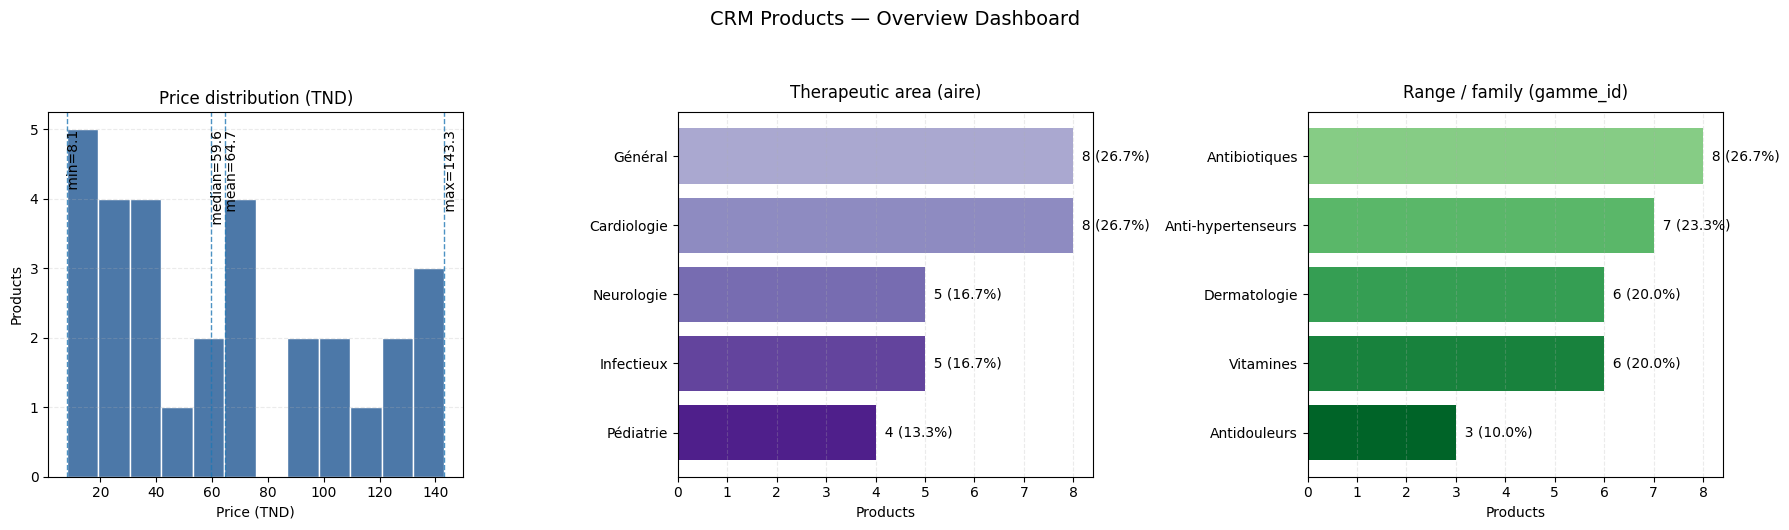


Insights (Products):
- Price range: 8.05 → 143.26 TND
- Mean price: 64.71 TND | Median price: 59.61 TND
- Most represented therapeutic area: Général (8 products)
- Most represented product range/category: Antibiotiques (8 products)


In [13]:
# --- Products dashboard (with label mapping for aire & gamme_id) ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

def barh_with_pct(ax, series, title, xlabel="Count", cmap="Blues"):
    series = series.copy()
    total = series.sum()
    labels = series.index.astype(str)
    values = series.values

    colors = getattr(plt.cm, cmap)(np.linspace(0.45, 0.9, len(series)))

    ax.barh(labels, values, color=colors)
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)

    for i, v in enumerate(values):
        pct = (v / total * 100) if total else 0
        ax.text(v, i, f"  {v} ({pct:.1f}%)", va="center")

    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.invert_yaxis()

def add_vline(ax, x, label):
    ax.axvline(x, linestyle="--", linewidth=1, alpha=0.8)
    ax.text(x, ax.get_ylim()[1]*0.95, f" {label}", rotation=90, va="top")

def build_map_from_lookup(lookup_list):
    """
    Build id -> label mapping from lookup_tables list of dicts.
    Tries common label keys: libelle/label/name/nom.
    """
    if not lookup_list or not isinstance(lookup_list, list):
        return {}

    label_keys = ["libelle", "label", "name", "nom", "titre", "designation"]
    out = {}
    for item in lookup_list:
        if not isinstance(item, dict) or "id" not in item:
            continue
        label_val = None
        for k in label_keys:
            if k in item and item[k] is not None:
                label_val = item[k]
                break
        if label_val is not None:
            out[item["id"]] = label_val
    return out

# --- Ensure products exist ---
if "products" not in globals() or products is None:
    raise ValueError("`products` is not defined. Please load CRM tables first.")

# --- Load CRM (to access lookup_tables) ---
CRM_PATH = Path("crm_dataset.json")
with open(CRM_PATH, "r", encoding="utf-8") as f:
    crm = json.load(f)

lookup_tables = crm.get("lookup_tables", {}) or {}

# --- Build mappings from lookup_tables (THIS IS THE FIX) ---
aire_map = build_map_from_lookup(lookup_tables.get("aires", []))

# For gamme_id, in your CRM it is usually prod_categories (not 'gammes')
gamme_map = build_map_from_lookup(lookup_tables.get("prod_categories", []))

# --- Add label columns to products (fallback if mapping missing) ---
prod_plot = products.copy()

if "aire" in prod_plot.columns:
    prod_plot["aire_label"] = prod_plot["aire"].map(aire_map)
    prod_plot["aire_label"] = prod_plot["aire_label"].fillna(
        prod_plot["aire"].apply(lambda x: f"Aire {x}" if pd.notna(x) else "NA")
    )

if "gamme_id" in prod_plot.columns:
    prod_plot["gamme_label"] = prod_plot["gamme_id"].map(gamme_map)
    prod_plot["gamme_label"] = prod_plot["gamme_label"].fillna(
        prod_plot["gamme_id"].apply(lambda x: f"Gamme {x}" if pd.notna(x) else "NA")
    )

# --- Plot dashboard ---
if prod_plot is not None and not prod_plot.empty:

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("CRM Products — Overview Dashboard", fontsize=14, y=1.05)

    # 1) Price histogram + stats lines
    if "prix" in prod_plot.columns:
        price = pd.to_numeric(prod_plot["prix"], errors="coerce").dropna()

        axes[0].hist(price, bins=12, color="#4C78A8", edgecolor="white")
        axes[0].set_title("Price distribution (TND)")
        axes[0].set_xlabel("Price (TND)")
        axes[0].set_ylabel("Products")
        axes[0].grid(axis="y", linestyle="--", alpha=0.25)

        if len(price) > 0:
            add_vline(axes[0], price.min(), f"min={price.min():.1f}")
            add_vline(axes[0], price.median(), f"median={price.median():.1f}")
            add_vline(axes[0], price.mean(), f"mean={price.mean():.1f}")
            add_vline(axes[0], price.max(), f"max={price.max():.1f}")
    else:
        axes[0].axis("off")
        axes[0].text(0.5, 0.5, "No 'prix' column", ha="center", va="center")

    # 2) Therapeutic area (aire) with labels
    if "aire_label" in prod_plot.columns:
        aire_s = prod_plot["aire_label"].fillna("NA").astype(str).value_counts()
        barh_with_pct(axes[1], aire_s, "Therapeutic area (aire)", xlabel="Products", cmap="Purples")
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "No 'aire' column", ha="center", va="center")

    # 3) Gamme/category with labels
    if "gamme_label" in prod_plot.columns:
        gamme_s = prod_plot["gamme_label"].fillna("NA").astype(str).value_counts()
        barh_with_pct(axes[2], gamme_s, "Range / family (gamme_id)", xlabel="Products", cmap="Greens")
    else:
        axes[2].axis("off")
        axes[2].text(0.5, 0.5, "No 'gamme_id' column", ha="center", va="center")

    plt.tight_layout()
    plt.show()

    # --- Insights (now with labels) ---
    print("\nInsights (Products):")

    if "prix" in prod_plot.columns:
        price = pd.to_numeric(prod_plot["prix"], errors="coerce").dropna()
        if len(price) > 0:
            print(f"- Price range: {price.min():.2f} → {price.max():.2f} TND")
            print(f"- Mean price: {price.mean():.2f} TND | Median price: {price.median():.2f} TND")

    if "aire_label" in prod_plot.columns:
        top_aire = prod_plot["aire_label"].fillna("NA").astype(str).value_counts().head(1)
        print(f"- Most represented therapeutic area: {top_aire.index[0]} ({top_aire.iloc[0]} products)")

    if "gamme_label" in prod_plot.columns:
        top_gamme = prod_plot["gamme_label"].fillna("NA").astype(str).value_counts().head(1)
        print(f"- Most represented product range/category: {top_gamme.index[0]} ({top_gamme.iloc[0]} products)")

else:
    print("Products table not found or empty.")

## 📊 Dashboard Summary

- Prices range from **8 to 143 TND**, with most products between **20–80 TND**.  
- **General** and **Cardiology** lead the therapeutic areas.  
- **Antibiotics** and **Anti-hypertensives** dominate product categories.  
- **Pediatrics** and **Analgesics** are the least represented segments.

**Overall:** The portfolio is focused on cardiovascular and general medicine, with balanced pricing and limited premium products.

## 1.5 Visits (if present) — Time Trends & Visit Types
If the CRM dataset contains a visits table (often `visites`), we analyze:
- visits per month
- distribution of visit types (if column exists)

,id,id_pros,id_visiteur,date_visite,type,commentaire,duree_min
0,1,36,5,2024-10-27,4,Suivi de la prescription en cours.,34
1,2,65,2,2023-07-23,1,Remise d'échantillons effectuée.,32
2,3,58,14,2025-04-27,3,"Visite rapide, informations laissées.",30
3,4,54,10,2024-10-02,4,"Pharmacien satisfait, commande prévue.",47
4,5,33,3,2023-11-09,4,"Médecin absent, rendez-vous reporté.",10


visites shape: (200, 7)


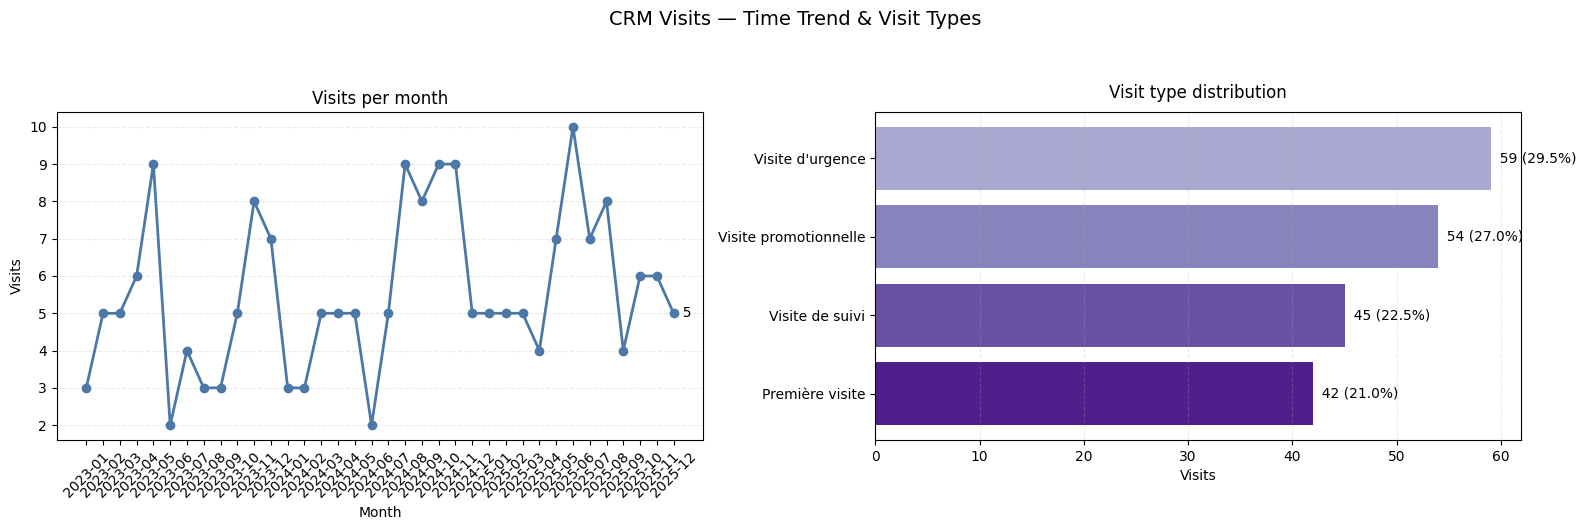


Insights (Visits):
- Most common visit type: Visite d'urgence (59 visits).


In [14]:
# --- 1.5 Visits — Time Trends & Visit Types (improved + labels + colors) ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

def barh_with_pct(ax, series, title, xlabel="Count", cmap="Blues"):
    series = series.copy()
    total = series.sum()
    labels = series.index.astype(str)
    values = series.values
    colors = getattr(plt.cm, cmap)(np.linspace(0.45, 0.9, len(series)))

    ax.barh(labels, values, color=colors)
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)

    for i, v in enumerate(values):
        pct = (v / total * 100) if total else 0
        ax.text(v, i, f"  {v} ({pct:.1f}%)", va="center")

    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.invert_yaxis()

# Load visits table
visits = crm_dfs.get("visites", pd.DataFrame())

if visits is None or visits.empty:
    print("No 'visites' table found in CRM dataset.")
else:
    display(visits.head(5))
    print("visites shape:", visits.shape)

    # --- Load lookup_tables (for labels) ---
    CRM_PATH = Path("crm_dataset.json")
    with open(CRM_PATH, "r", encoding="utf-8") as f:
        crm = json.load(f)

    lookup_tables = crm.get("lookup_tables", {}) or {}

    # Build mapping for visit types: id -> libelle
    type_visite_map = {}
    if "type_visites" in lookup_tables:
        type_visite_map = {d["id"]: d.get("libelle", f"Type {d['id']}") for d in lookup_tables["type_visites"]}

    # --- Detect & parse date column (include 'date_visite') ---
    date_col_candidates = [c for c in visits.columns if c.lower() in
                           ("date", "visit_date", "created_at", "datetime", "date_visite")]
    date_col = date_col_candidates[0] if date_col_candidates else None

    # --- Create dashboard: monthly trend + visit type distribution ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("CRM Visits — Time Trend & Visit Types", fontsize=14, y=1.05)

    # (A) Visits per month
    if date_col:
        v = visits.copy()
        v[date_col] = pd.to_datetime(v[date_col], errors="coerce")
        v = v.dropna(subset=[date_col])

        if not v.empty:
            v["month"] = v[date_col].dt.to_period("M").astype(str)
            monthly = v["month"].value_counts().sort_index()

            axes[0].plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#4C78A8")
            axes[0].set_title("Visits per month")
            axes[0].set_xlabel("Month")
            axes[0].set_ylabel("Visits")
            axes[0].grid(axis="y", linestyle="--", alpha=0.25)
            axes[0].tick_params(axis="x", rotation=45)

            # annotate last point
            axes[0].text(len(monthly.index)-1, monthly.values[-1], f"  {monthly.values[-1]}", va="center")
        else:
            axes[0].axis("off")
            axes[0].text(0.5, 0.5, "Dates could not be parsed.", ha="center", va="center")
    else:
        axes[0].axis("off")
        axes[0].text(0.5, 0.5, "No date column found.", ha="center", va="center")

    # (B) Visit type distribution (with labels)
    type_col = None
    for col in ["type_visite", "visit_type", "type"]:
        if col in visits.columns:
            type_col = col
            break

    if type_col:
        tmp = visits.copy()
        # Convert to numeric for mapping
        tmp[type_col] = pd.to_numeric(tmp[type_col], errors="coerce")

        # Create label column
        tmp["visit_type_label"] = tmp[type_col].map(type_visite_map)
        tmp["visit_type_label"] = tmp["visit_type_label"].fillna(tmp[type_col].apply(lambda x: f"Type {int(x)}" if pd.notna(x) else "NA"))

        type_counts = tmp["visit_type_label"].value_counts()
        barh_with_pct(axes[1], type_counts, "Visit type distribution", xlabel="Visits", cmap="Purples")
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "No visit type column found.", ha="center", va="center")

    plt.tight_layout()
    plt.show()

    # --- Non-vague insights ---
    print("\nInsights (Visits):")
    if date_col and "month" in locals() and 'monthly' in locals() and len(monthly) > 0:
        print(f"- Time span: {monthly.index.min()} → {monthly.index.max()} ({len(monthly)} months with visits).")
        peak_month = monthly.idxmax()
        print(f"- Peak month: {peak_month} with {monthly.max()} visits.")

    if type_col:
        top_type = type_counts.head(1)
        print(f"- Most common visit type: {top_type.index[0]} ({top_type.iloc[0]} visits).")

## 📊 Visits Analysis Summary

### 📈 Monthly Trend
- Visit activity fluctuates between **2 and 10 visits per month**.
- A peak is observed around **mid-2025**, indicating increased field activity.
- Overall trend shows relatively stable engagement with moderate variability over time.

### 🏥 Visit Type Distribution
- **Emergency visits** are the most frequent (29.5%), suggesting reactive interventions.
- **Promotional visits** follow closely (27%), reflecting strong commercial activity.
- **Follow-up visits** (22.5%) and **First visits** (21%) are slightly less common but still balanced.

### 🎯 Conclusion
Field activity is consistent over time, with a strong focus on **urgent and promotional visits**, indicating a mix of reactive and proactive engagement strategies.

## 1.6 Data Quality Snapshot (CRM)
We check missingness for the key tables.


🧪 Data Quality — CRM.users
- Rows: 20 | Columns: 13
- Columns with missing values: 2


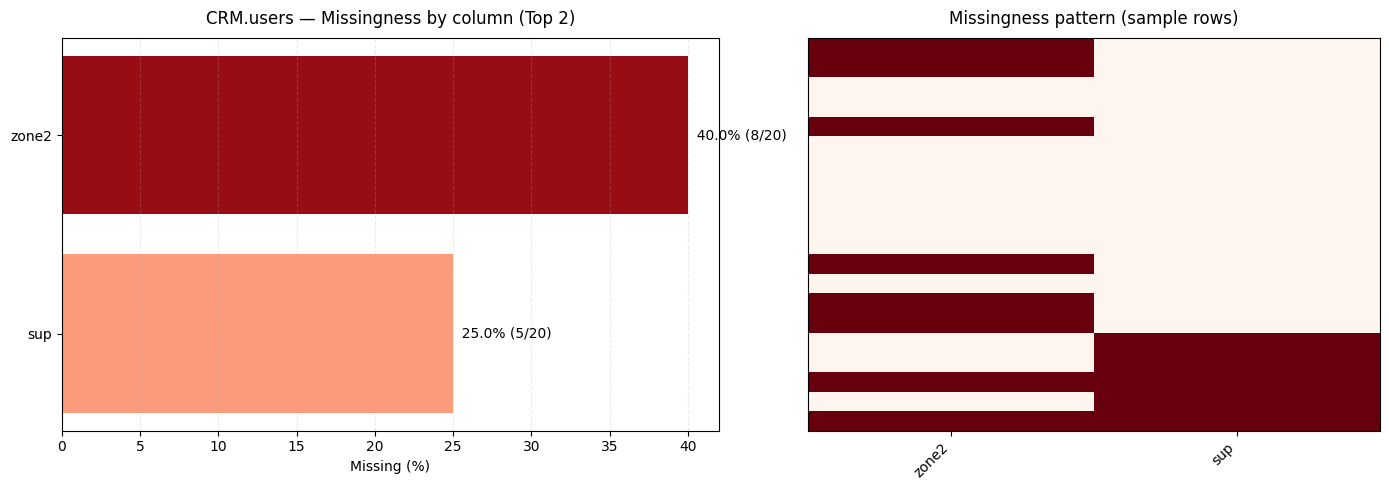

- Highest missing column: 'zone2' = 40.0% (8/20)

🧪 Data Quality — CRM.products
- Rows: 30 | Columns: 8
- Columns with missing values: 0
- No missing values detected ✅
CRM.visites: not found or empty.


In [16]:
# --- 1.6 Data Quality Snapshot (CRM) — improved visuals + clearer insights ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def missingness_dashboard(df: pd.DataFrame, table_name: str, top_n: int = 12):
    """
    Shows:
    1) Bar chart of missingness (%) for columns with missing values (Top N)
    2) Heatmap-like matrix (rows x missing columns) for quick pattern spotting (small sample)
    Also prints a short numeric summary.
    """
    if df is None or df.empty:
        print(f"{table_name}: empty or not found.")
        return

    n_rows = len(df)
    miss_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    miss_pct = miss_pct[miss_pct > 0]

    print(f"\n🧪 Data Quality — {table_name}")
    print(f"- Rows: {n_rows} | Columns: {df.shape[1]}")
    print(f"- Columns with missing values: {len(miss_pct)}")

    if miss_pct.empty:
        print("- No missing values detected ✅")
        return

    # Keep top N missing columns for readability
    miss_pct_top = miss_pct.head(top_n)
    miss_count_top = df[miss_pct_top.index].isna().sum()

    # ---- Figure layout (bar + heatmap) ----
    fig = plt.figure(figsize=(14, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    # (A) Bar chart with colors + annotations
    y_labels = miss_pct_top.index.astype(str)[::-1]
    x_vals = miss_pct_top.values[::-1]
    colors = plt.cm.Reds(np.linspace(0.35, 0.9, len(x_vals)))

    ax1.barh(y_labels, x_vals, color=colors)
    ax1.set_title(f"{table_name} — Missingness by column (Top {len(miss_pct_top)})", pad=10)
    ax1.set_xlabel("Missing (%)")
    ax1.grid(axis="x", linestyle="--", alpha=0.25)

    # Annotate with % and counts
    for i, col in enumerate(miss_pct_top.index[::-1]):
        pct = miss_pct_top[col]
        cnt = miss_count_top[col]
        ax1.text(pct, i, f"  {pct:.1f}% ({cnt}/{n_rows})", va="center")

    # (B) Heatmap-like missing pattern (sampled rows to keep readable)
    cols = miss_pct_top.index.tolist()
    sample = df[cols].copy()

    # Limit rows displayed (heatmap becomes unreadable otherwise)
    max_rows = 40
    if len(sample) > max_rows:
        sample = sample.sample(max_rows, random_state=42).reset_index(drop=True)
    else:
        sample = sample.reset_index(drop=True)

    # Missing matrix: 1 if missing else 0
    mat = sample.isna().astype(int).values

    ax2.imshow(mat, aspect="auto", interpolation="nearest", cmap="Reds")
    ax2.set_title("Missingness pattern (sample rows)", pad=10)
    ax2.set_yticks([])

    ax2.set_xticks(range(len(cols)))
    ax2.set_xticklabels(cols, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    # Short actionable insight
    worst_col = miss_pct.idxmax()
    worst_pct = miss_pct.max()
    worst_cnt = df[worst_col].isna().sum()
    print(f"- Highest missing column: '{worst_col}' = {worst_pct:.1f}% ({worst_cnt}/{n_rows})")

# Run snapshot for key tables
for name in ["users", "products", "visites"]:
    df = locals().get(name, pd.DataFrame())
    if df is not None and not df.empty:
        missingness_dashboard(df, table_name=f"CRM.{name}", top_n=12)
    else:
        print(f"CRM.{name}: not found or empty.")

## 📊 Data Quality — CRM.users

- **zone2:** 40% missing (8/20)  
- **sup:** 25% missing (5/20)

### Interpretation
- Missing values in **zone2** are likely normal (secondary zone is optional).
- Missing values in **sup** are expected for supervisors/admins.

### Conclusion
The missingness appears **structural and business-related**, not a data quality issue.

##1.7 Top 5 Medical Representatives by Visits (with Names & Zone Comparison)
* Identifies the Top 5 most active medical reps by total visits

* Displays representative names (merged from users table)

* Compares visit distribution across zones

* Helps detect top performers and territorial focus patterns

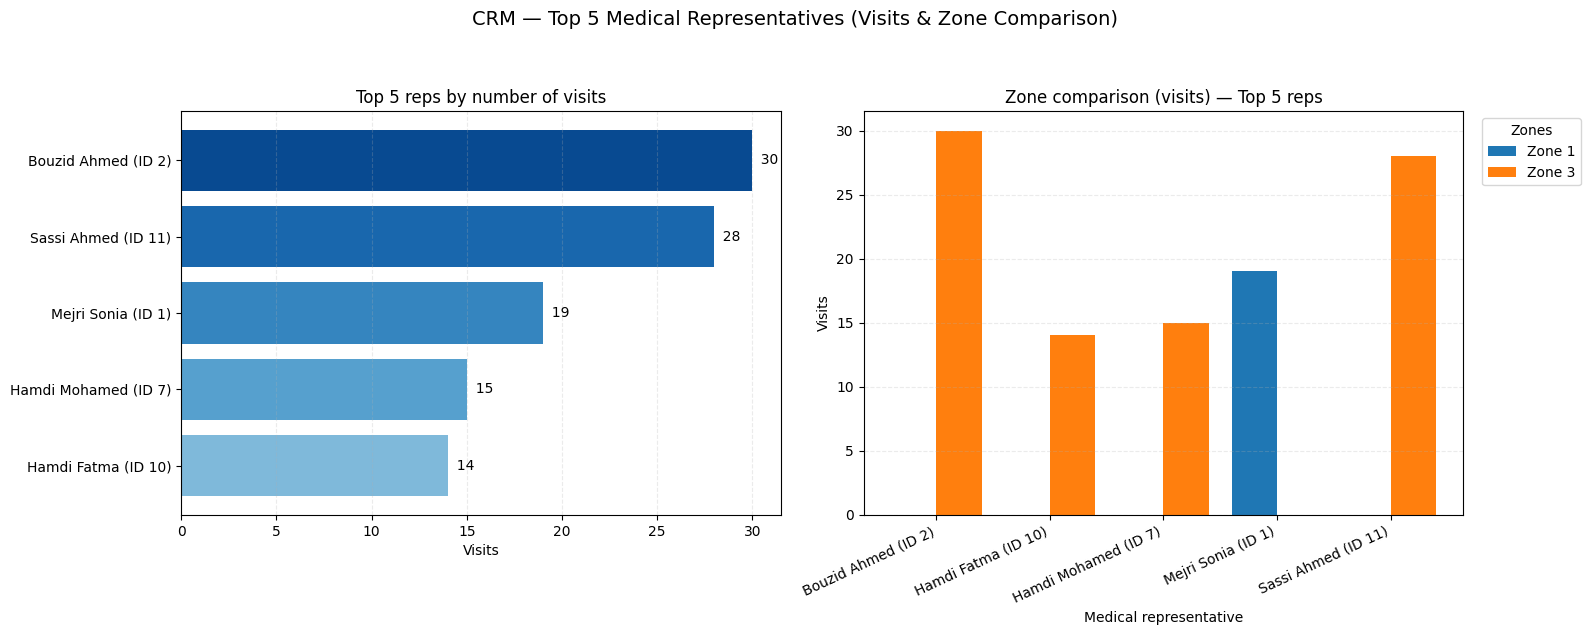


📌 Insights (Top 5):


,id_visiteur,rep_name,zone,visits
0,2,Bouzid Ahmed,3,30
1,11,Sassi Ahmed,3,28
2,1,Mejri Sonia,1,19
3,7,Hamdi Mohamed,3,15
4,10,Hamdi Fatma,3,14



📌 Zone distribution for visits (Top 5 reps only):


,zone,visits
0,3,87
1,1,19


In [19]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load tables
visits = crm_dfs.get("visites", pd.DataFrame())
users = crm_dfs.get("users", pd.DataFrame())

if visits is None or visits.empty:
    print("No 'visites' table found in CRM dataset.")
elif users is None or users.empty:
    print("No 'users' table found in CRM dataset.")
else:
    # ---- 1) Visits per rep ----
    vpu = visits["id_visiteur"].value_counts().rename_axis("id_visiteur").reset_index(name="visits")

    # ---- 2) Merge with users to get names + zone ----
    u = users.copy()

    # Create readable name
    if "Nom" in u.columns and "Prenom" in u.columns:
        u["rep_name"] = (u["Nom"].fillna("") + " " + u["Prenom"].fillna("")).str.strip()
    elif "name" in u.columns:
        u["rep_name"] = u["name"].astype(str)
    else:
        u["rep_name"] = u["id"].astype(str)

    # Ensure zone exists
    if "zone" not in u.columns:
        u["zone"] = "NA"

    u_small = u[["id", "rep_name", "zone"]].rename(columns={"id": "id_visiteur"})

    merged = vpu.merge(u_small, on="id_visiteur", how="left")

    # Fill fallback labels if missing
    merged["rep_name"] = merged["rep_name"].fillna(merged["id_visiteur"].apply(lambda x: f"Rep {x}"))
    merged["zone"] = merged["zone"].fillna("NA").astype(str)

    # ---- 3) Top 5 only ----
    top5 = merged.sort_values("visits", ascending=False).head(5).copy()

    # Label to display on plots
    top5["label"] = top5["rep_name"] + " (ID " + top5["id_visiteur"].astype(str) + ")"

    # ---- Plot A: Top 5 reps by number of visits ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("CRM — Top 5 Medical Representatives (Visits & Zone Comparison)", fontsize=14, y=1.05)

    # Horizontal bar chart (Top 5)
    top5_sorted = top5.sort_values("visits", ascending=True)
    colors = plt.cm.Blues(np.linspace(0.45, 0.9, len(top5_sorted)))

    axes[0].barh(top5_sorted["label"], top5_sorted["visits"], color=colors)
    axes[0].set_title("Top 5 reps by number of visits")
    axes[0].set_xlabel("Visits")
    axes[0].grid(axis="x", linestyle="--", alpha=0.25)

    # Add value labels
    for i, v in enumerate(top5_sorted["visits"].values):
        axes[0].text(v, i, f"  {v}", va="center")

    # ---- Plot B: Zone comparison for Top 5 reps ----
    # Join visits with users (zone) then filter to top reps
    visits_zone = visits.merge(u_small, on="id_visiteur", how="left")
    visits_zone["zone"] = visits_zone["zone"].fillna("NA").astype(str)

    # Keep only visits from top5 reps
    visits_zone = visits_zone[visits_zone["id_visiteur"].isin(top5["id_visiteur"])]

    # Count visits by (rep, zone)
    zone_counts = (
        visits_zone.groupby(["id_visiteur", "zone"])
        .size()
        .reset_index(name="visits")
        .merge(top5[["id_visiteur", "label"]], on="id_visiteur", how="left")
    )

    # Pivot: rows = reps, columns = zones
    pivot = zone_counts.pivot_table(index="label", columns="zone", values="visits", fill_value=0)

    # Bar chart (grouped)
    zones = pivot.columns.tolist()
    x = np.arange(len(pivot.index))
    width = 0.8 / max(len(zones), 1)

    for j, z in enumerate(zones):
        axes[1].bar(x + j * width, pivot[z].values, width=width, label=f"Zone {z}")

    axes[1].set_title("Zone comparison (visits) — Top 5 reps")
    axes[1].set_xlabel("Medical representative")
    axes[1].set_ylabel("Visits")
    axes[1].set_xticks(x + (len(zones)-1) * width / 2)
    axes[1].set_xticklabels(pivot.index, rotation=25, ha="right")
    axes[1].grid(axis="y", linestyle="--", alpha=0.25)
    axes[1].legend(title="Zones", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    # ---- Insights ----
    print("\n📌 Insights (Top 5):")
    display(top5[["id_visiteur", "rep_name", "zone", "visits"]].reset_index(drop=True))

    # Zone summary across top 5
    zone_summary = visits_zone["zone"].value_counts().rename_axis("zone").reset_index(name="visits")
    print("\n📌 Zone distribution for visits (Top 5 reps only):")
    display(zone_summary)

##1.8 Visits per Zone (Territorial Coverage Analysis)
* Measures territorial coverage by counting visits per zone

* Highlights most vs least active zones

* Adds an average-per-zone benchmark to spot imbalances

* Flags under-exploited zones (below-average visit volume)

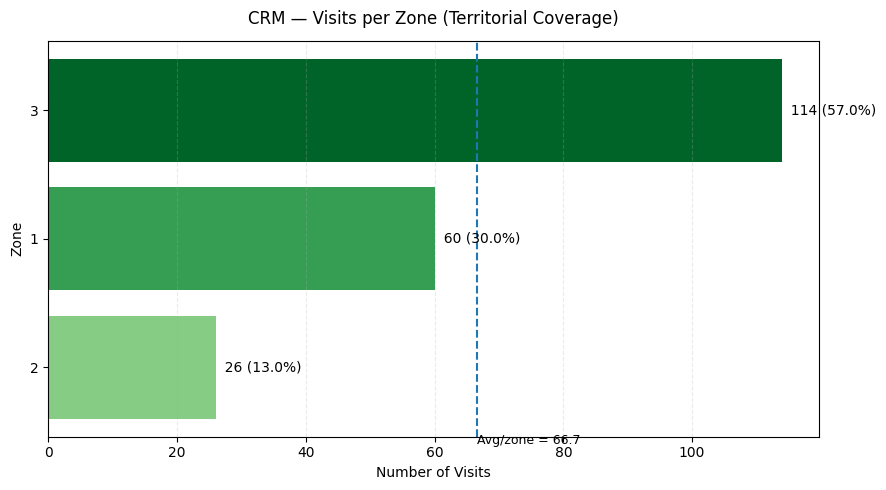


📌 Insights:
- Total visits: 200
- Zones found: 3
- Average visits per zone: 66.67
- Most active zone: 3 (114 visits)
- Least active zone: 2 (26 visits)

⚠️ Under-exploited zones (below average visits):


,visits
zone,
2,26
1,60


In [20]:
# --- BO2: Visits per Zone (Coverage Analysis) ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load tables
visits = crm_dfs.get("visites", pd.DataFrame())
users  = crm_dfs.get("users", pd.DataFrame())

if visits is None or visits.empty:
    print("No 'visites' table found in CRM dataset.")
elif users is None or users.empty:
    print("No 'users' table found in CRM dataset.")
else:
    # Keep only needed columns
    u = users[["id", "zone"]].copy() if "zone" in users.columns else users[["id"]].assign(zone="NA")
    u = u.rename(columns={"id": "id_visiteur"})
    u["zone"] = u["zone"].fillna("NA").astype(str)

    # Merge visits with user zones
    v = visits.merge(u, on="id_visiteur", how="left")
    v["zone"] = v["zone"].fillna("NA").astype(str)

    # Count visits per zone
    zone_counts = v["zone"].value_counts().sort_values(ascending=True)
    total_visits = len(v)

    # Determine "under-exploited" zones (below average visits per zone)
    avg_per_zone = zone_counts.mean()
    under_zones = zone_counts[zone_counts < avg_per_zone]

    # --- Plot (horizontal bar) ---
    fig, ax = plt.subplots(figsize=(9, 5))

    colors = plt.cm.Greens(np.linspace(0.45, 0.9, len(zone_counts)))
    ax.barh(zone_counts.index, zone_counts.values, color=colors)

    ax.set_title("CRM — Visits per Zone (Territorial Coverage)", pad=12)
    ax.set_xlabel("Number of Visits")
    ax.set_ylabel("Zone")
    ax.grid(axis="x", linestyle="--", alpha=0.25)

    # Add labels (% and count)
    for i, (z, c) in enumerate(zip(zone_counts.index, zone_counts.values)):
        pct = (c / total_visits) * 100
        ax.text(c, i, f"  {c} ({pct:.1f}%)", va="center")

    # Average reference line
    ax.axvline(avg_per_zone, linestyle="--", linewidth=1.5)
    ax.text(avg_per_zone, -0.6, f"Avg/zone = {avg_per_zone:.1f}", fontsize=9, ha="left")

    plt.tight_layout()
    plt.show()

    # --- Insights ---
    print("\n📌 Insights:")
    print(f"- Total visits: {total_visits}")
    print(f"- Zones found: {len(zone_counts)}")
    print(f"- Average visits per zone: {avg_per_zone:.2f}")
    print(f"- Most active zone: {zone_counts.idxmax()} ({zone_counts.max()} visits)")
    print(f"- Least active zone: {zone_counts.idxmin()} ({zone_counts.min()} visits)")

    if len(under_zones) > 0:
        print("\n⚠️ Under-exploited zones (below average visits):")
        display(under_zones.rename("visits").to_frame())
    else:
        print("\n✅ No under-exploited zones detected (all zones are >= average).")

##1.9 Visit Duration Analysis (Engagement Indicator)
* Shows the overall distribution of visit durations (minutes)

* Adds the mean duration as a reference line

* Compares average duration by visit type (labeled from lookup table)

* Helps assess engagement level and detect short vs deep interactions

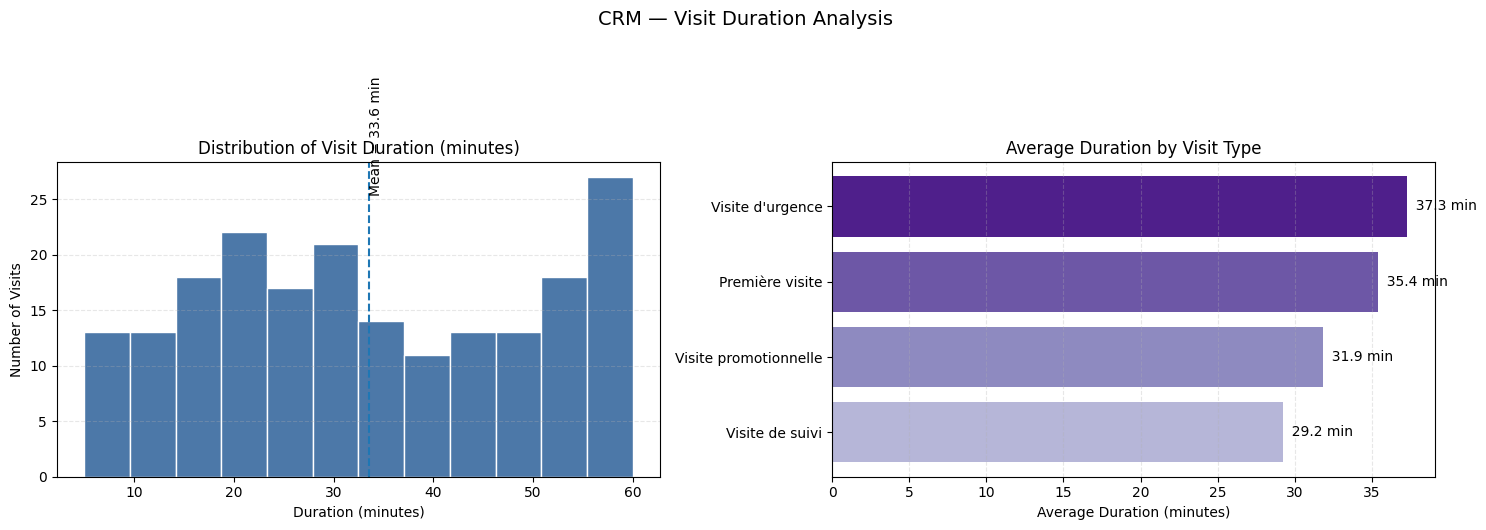


📌 Insights:
- Overall average visit duration: 33.60 minutes
- Longest average duration: Visite d'urgence (37.25 min)
- Shortest average duration: Visite de suivi (29.22 min)


In [21]:
# --- BO2: Visit Duration Analysis (Engagement Indicator) ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json

visits = crm_dfs.get("visites", pd.DataFrame())

if visits is None or visits.empty:
    print("No 'visites' table found in CRM dataset.")
else:

    # Ensure duration column exists
    if "duree_min" not in visits.columns:
        print("Column 'duree_min' not found in visites table.")
    else:

        v = visits.copy()
        v["duree_min"] = pd.to_numeric(v["duree_min"], errors="coerce")
        v = v.dropna(subset=["duree_min"])

        if v.empty:
            print("No valid duration values found.")
        else:

            # ---- Load visit type labels ----
            with open("crm_dataset.json", "r", encoding="utf-8") as f:
                crm = json.load(f)

            lookup_tables = crm.get("lookup_tables", {})
            type_map = {}

            if "type_visites" in lookup_tables:
                type_map = {d["id"]: d.get("libelle", f"Type {d['id']}")
                            for d in lookup_tables["type_visites"]}

            if "type" in v.columns:
                v["visit_type_label"] = v["type"].map(type_map)
                v["visit_type_label"] = v["visit_type_label"].fillna(
                    v["type"].apply(lambda x: f"Type {x}")
                )
            else:
                v["visit_type_label"] = "Unknown"

            # ---- Create figure ----
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            fig.suptitle("CRM — Visit Duration Analysis", fontsize=14, y=1.05)

            # (A) Histogram of durations
            axes[0].hist(v["duree_min"], bins=12, color="#4C78A8", edgecolor="white")
            axes[0].set_title("Distribution of Visit Duration (minutes)")
            axes[0].set_xlabel("Duration (minutes)")
            axes[0].set_ylabel("Number of Visits")
            axes[0].grid(axis="y", linestyle="--", alpha=0.3)

            avg_duration = v["duree_min"].mean()
            axes[0].axvline(avg_duration, linestyle="--", linewidth=1.5)
            axes[0].text(avg_duration, axes[0].get_ylim()[1]*0.9,
                         f"Mean = {avg_duration:.1f} min", rotation=90)

            # (B) Average duration per visit type
            duration_by_type = (
                v.groupby("visit_type_label")["duree_min"]
                .mean()
                .sort_values(ascending=True)
            )

            colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(duration_by_type)))
            axes[1].barh(duration_by_type.index, duration_by_type.values, color=colors)

            axes[1].set_title("Average Duration by Visit Type")
            axes[1].set_xlabel("Average Duration (minutes)")
            axes[1].grid(axis="x", linestyle="--", alpha=0.3)

            for i, val in enumerate(duration_by_type.values):
                axes[1].text(val, i, f"  {val:.1f} min", va="center")

            plt.tight_layout()
            plt.show()

            # ---- Insights ----
            longest_type = duration_by_type.idxmax()
            shortest_type = duration_by_type.idxmin()

            print("\n📌 Insights:")
            print(f"- Overall average visit duration: {avg_duration:.2f} minutes")
            print(f"- Longest average duration: {longest_type} ({duration_by_type.max():.2f} min)")
            print(f"- Shortest average duration: {shortest_type} ({duration_by_type.min():.2f} min)")

##1.10 Visit Type Strategy (by User & by Zone)
* Compares visit type distribution across zones

* Highlights dominant visit type per zone

* Helps understand field strategy patterns (promotional vs follow-up vs urgent, etc.)

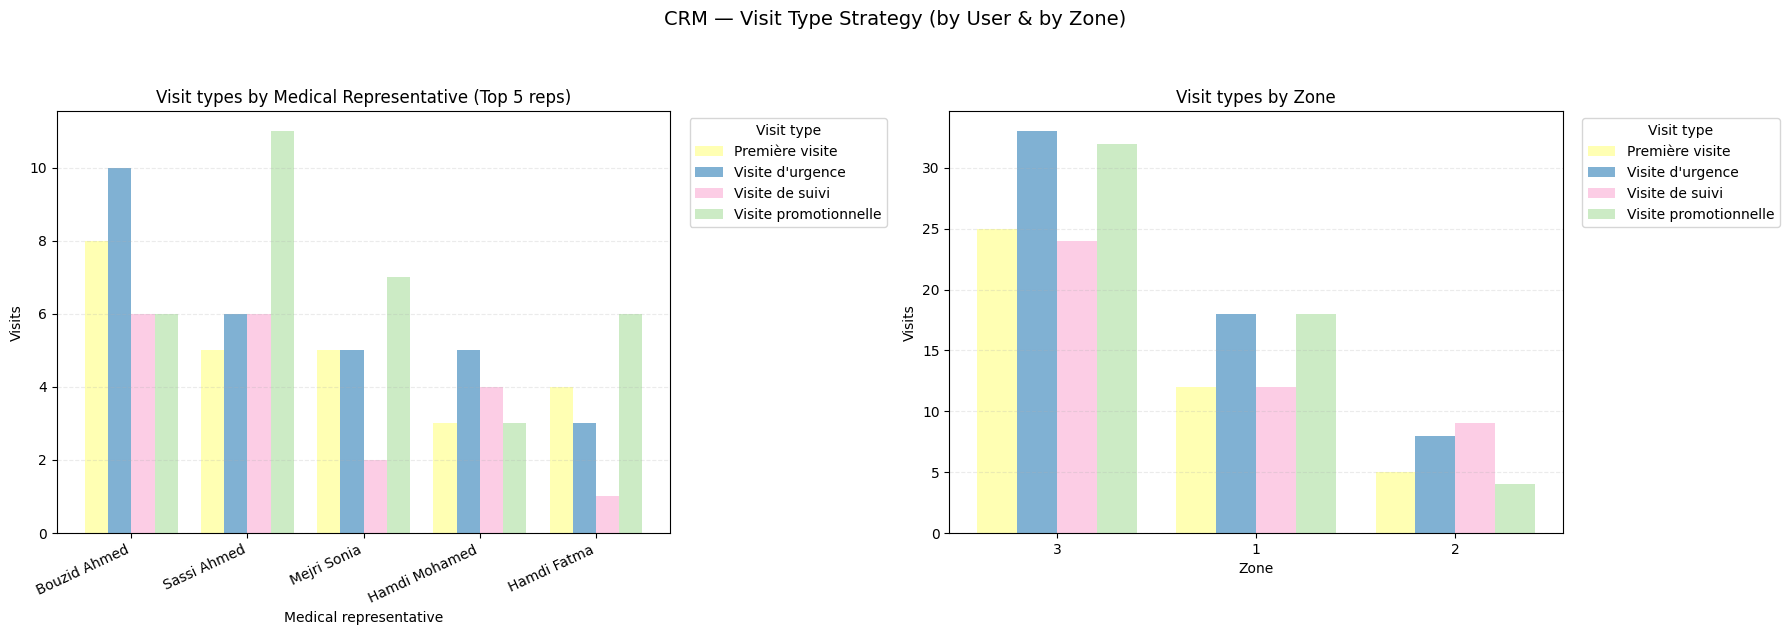


📌 Insights:
- Top 5 reps used for user breakdown: ['Bouzid Ahmed', 'Sassi Ahmed', 'Mejri Sonia', 'Hamdi Mohamed', 'Hamdi Fatma']
- Dominant visit type by zone:


,dominant_visit_type
zone,
3,Visite d'urgence
1,Visite d'urgence
2,Visite de suivi


In [23]:
# --- BO2 (Advanced): Visit Type Strategy — by User (Top 5) & by Zone ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

# Load tables
visits = crm_dfs.get("visites", pd.DataFrame())
users  = crm_dfs.get("users", pd.DataFrame())

if visits is None or visits.empty:
    print("No 'visites' table found in CRM dataset.")
elif users is None or users.empty:
    print("No 'users' table found in CRM dataset.")
else:
    # --- Load visit type labels from lookup_tables ---
    CRM_PATH = Path("crm_dataset.json")
    with open(CRM_PATH, "r", encoding="utf-8") as f:
        crm = json.load(f)

    lookup_tables = crm.get("lookup_tables", {}) or {}
    type_map = {}
    if "type_visites" in lookup_tables:
        type_map = {d["id"]: d.get("libelle", f"Type {d['id']}") for d in lookup_tables["type_visites"]}

    # --- Identify visit type column ---
    type_col = None
    for c in ["type_visite", "visit_type", "type"]:
        if c in visits.columns:
            type_col = c
            break

    if type_col is None:
        print("No visit type column found (expected one of: type_visite / visit_type / type).")
    else:
        # Clean & enrich
        v = visits.copy()

        # Make numeric for mapping
        v[type_col] = pd.to_numeric(v[type_col], errors="coerce")

        # Add type labels
        v["visit_type_label"] = v[type_col].map(type_map)
        v["visit_type_label"] = v["visit_type_label"].fillna(
            v[type_col].apply(lambda x: f"Type {int(x)}" if pd.notna(x) else "Unknown")
        )

        # Add user info: name + zone
        u = users.copy()
        if "Nom" in u.columns and "Prenom" in u.columns:
            u["rep_name"] = (u["Nom"].fillna("") + " " + u["Prenom"].fillna("")).str.strip()
        else:
            u["rep_name"] = u.get("login", u.get("id", "Unknown")).astype(str)

        if "zone" not in u.columns:
            u["zone"] = "NA"

        u = u[["id", "rep_name", "zone"]].rename(columns={"id": "id_visiteur"})
        u["zone"] = u["zone"].fillna("NA").astype(str)

        # Merge
        v = v.merge(u, on="id_visiteur", how="left")
        v["rep_name"] = v["rep_name"].fillna(v["id_visiteur"].apply(lambda x: f"Rep {x}"))
        v["zone"] = v["zone"].fillna("NA").astype(str)

        # --- A) Visit type by USER (Top 5 reps by total visits) ---
        top5_ids = v["id_visiteur"].value_counts().head(5).index
        v_top = v[v["id_visiteur"].isin(top5_ids)].copy()

        pivot_user = pd.crosstab(v_top["rep_name"], v_top["visit_type_label"])
        pivot_user = pivot_user.loc[pivot_user.sum(axis=1).sort_values(ascending=False).index]  # sort by activity

        # --- B) Visit type by ZONE ---
        pivot_zone = pd.crosstab(v["zone"], v["visit_type_label"])
        pivot_zone = pivot_zone.loc[pivot_zone.sum(axis=1).sort_values(ascending=False).index]

        # --- Plot ---
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle("CRM — Visit Type Strategy (by User & by Zone)", fontsize=14, y=1.05)

        # Colors per visit type
        visit_types = sorted(v["visit_type_label"].unique())
        colors = plt.cm.Set3(np.linspace(0.1, 0.9, len(visit_types)))

        # Plot A: grouped bars (user)
        x = np.arange(len(pivot_user.index))
        width = 0.8 / max(len(pivot_user.columns), 1)

        for j, col in enumerate(pivot_user.columns):
            c = colors[j % len(colors)]
            axes[0].bar(x + j * width, pivot_user[col].values, width=width, label=col, color=c)

        axes[0].set_title("Visit types by Medical Representative (Top 5 reps)")
        axes[0].set_xlabel("Medical representative")
        axes[0].set_ylabel("Visits")
        axes[0].set_xticks(x + (len(pivot_user.columns)-1) * width / 2)
        axes[0].set_xticklabels(pivot_user.index, rotation=25, ha="right")
        axes[0].grid(axis="y", linestyle="--", alpha=0.25)
        axes[0].legend(title="Visit type", bbox_to_anchor=(1.02, 1), loc="upper left")

        # Plot B: grouped bars (zone)
        x2 = np.arange(len(pivot_zone.index))
        width2 = 0.8 / max(len(pivot_zone.columns), 1)

        for j, col in enumerate(pivot_zone.columns):
            c = colors[j % len(colors)]
            axes[1].bar(x2 + j * width2, pivot_zone[col].values, width=width2, label=col, color=c)

        axes[1].set_title("Visit types by Zone")
        axes[1].set_xlabel("Zone")
        axes[1].set_ylabel("Visits")
        axes[1].set_xticks(x2 + (len(pivot_zone.columns)-1) * width2 / 2)
        axes[1].set_xticklabels(pivot_zone.index, rotation=0)
        axes[1].grid(axis="y", linestyle="--", alpha=0.25)
        axes[1].legend(title="Visit type", bbox_to_anchor=(1.02, 1), loc="upper left")

        plt.tight_layout()
        plt.show()

        # --- Quick insights (non-vague) ---
        print("\n📌 Insights:")
        print("- Top 5 reps used for user breakdown:", list(pivot_user.index))
        dominant_by_zone = pivot_zone.idxmax(axis=1)
        print("- Dominant visit type by zone:")
        display(dominant_by_zone.rename("dominant_visit_type").to_frame())

##1.11 Coverage Heatmap (Visits by Zone × Medical Specialty)
* Links visits to rep zones (users.zone) and doctor specialties (prospects.spec)

* Visualizes market coverage using a Zone × Specialty heatmap

* Highlights high-activity segments (hot cells) and coverage gaps (0-visit cells)

* Useful to detect under-served specialties or zones and guide field strategy

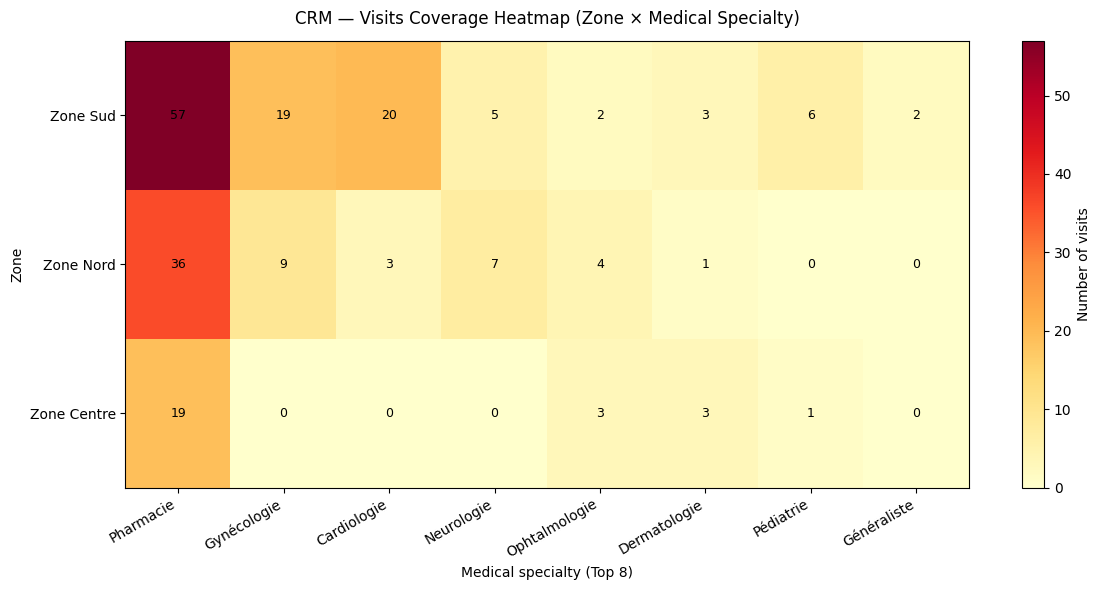


📌 Insights:
- Total linked visits (zone + specialty): 200
- Most active zone: Zone Sud (114 visits)
- Most visited specialty: Pharmacie (112 visits)
- Coverage gaps (0 cells in zone×specialty grid): 6


In [26]:
# --- BO2 (Advanced): Coverage Heatmap — Visits by Zone × Specialty ---

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

# Tables
visits = crm_dfs.get("visites", pd.DataFrame())
users = crm_dfs.get("users", pd.DataFrame())
prospects = crm_dfs.get("prospects", pd.DataFrame())

if visits is None or visits.empty:
    print("No 'visites' table found.")
elif users is None or users.empty:
    print("No 'users' table found.")
elif prospects is None or prospects.empty:
    print("No 'prospects' table found.")
else:
    # --- Load lookup labels (zones + specialites) ---
    CRM_PATH = Path("./crm_dataset.json")
    if not CRM_PATH.exists():
        for p in [Path("/mnt/data/crm_dataset.json"), Path("crm_dataset.json")]:
            if p.exists():
                CRM_PATH = p
                break

    lookup_tables = {}
    if CRM_PATH.exists():
        with open(CRM_PATH, "r", encoding="utf-8") as f:
            crm_json = json.load(f)
        lookup_tables = crm_json.get("lookup_tables", {}) or {}

    def build_lookup_map(lookup_list, id_key="id", label_keys=("libelle","label","name","nom")):
        if not isinstance(lookup_list, list):
            return {}
        m = {}
        for d in lookup_list:
            if not isinstance(d, dict) or id_key not in d:
                continue
            lab = None
            for k in label_keys:
                if k in d and pd.notna(d[k]):
                    lab = d[k]
                    break
            m[d[id_key]] = lab if lab else f"{id_key}={d[id_key]}"
        return m

    zone_map = build_lookup_map(lookup_tables.get("zones", []))
    spec_map = build_lookup_map(lookup_tables.get("specialites", []))

    # --- Merge: visits → users (zone), visits → prospects (spec) ---
    v = visits[["id_visiteur", "id_pros"]].copy()
    v["id_visiteur"] = pd.to_numeric(v["id_visiteur"], errors="coerce")
    v["id_pros"] = pd.to_numeric(v["id_pros"], errors="coerce")

    u = users[["id", "zone"]].rename(columns={"id": "id_visiteur"}).copy()
    u["zone"] = pd.to_numeric(u["zone"], errors="coerce")

    p = prospects[["id", "spec"]].rename(columns={"id": "id_pros"}).copy()
    p["spec"] = pd.to_numeric(p["spec"], errors="coerce")

    merged = v.merge(u, on="id_visiteur", how="left").merge(p, on="id_pros", how="left")

    # --- Labels ---
    merged["zone_label"] = merged["zone"].map(zone_map)
    merged["zone_label"] = merged["zone_label"].fillna(
        merged["zone"].apply(lambda x: f"Zone {int(x)}" if pd.notna(x) else "Unknown zone")
    )

    merged["spec_label"] = merged["spec"].map(spec_map)
    merged["spec_label"] = merged["spec_label"].fillna(
        merged["spec"].apply(lambda x: f"Specialty {int(x)}" if pd.notna(x) else "Unknown specialty")
    )

    # --- Pivot (counts) ---
    pivot = pd.crosstab(merged["zone_label"], merged["spec_label"])

    # Keep top specialties for readability
    TOP_SPECS = 8
    top_specs = pivot.sum(axis=0).sort_values(ascending=False).head(TOP_SPECS).index
    pivot = pivot[top_specs]

    # Sort zones by activity
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # --- Plot heatmap ---
    mat = pivot.values
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(mat, aspect="auto", interpolation="nearest", cmap="YlOrRd")

    ax.set_title("CRM — Visits Coverage Heatmap (Zone × Medical Specialty)", pad=12)
    ax.set_xlabel("Medical specialty (Top 8)")
    ax.set_ylabel("Zone")

    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)

    # Cell annotations (counts)
    if mat.size <= 250:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, int(mat[i, j]), ha="center", va="center", fontsize=9)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Number of visits")

    plt.tight_layout()
    plt.show()

    # --- Insights ---
    total_linked = int(mat.sum())
    top_zone = pivot.sum(axis=1).idxmax()
    top_spec = pivot.sum(axis=0).idxmax()
    zero_cells = int((pivot == 0).sum().sum())

    print("\n📌 Insights:")
    print(f"- Total linked visits (zone + specialty): {total_linked}")
    print(f"- Most active zone: {top_zone} ({int(pivot.loc[top_zone].sum())} visits)")
    print(f"- Most visited specialty: {top_spec} ({int(pivot[top_spec].sum())} visits)")
    print(f"- Coverage gaps (0 cells in zone×specialty grid): {zero_cells}")

# 2) Conversation / Visits Dataset (`vital_bo6_datasetProduit.json`)
This dataset contains **realistic visit interactions**, typically with:
- language (FR/EN/AR)
- doctor persona/specialty
- objection type
- sentiment/engagement/interest scores
- raw transcript + structured turns JSON + a CRM-like report JSON

We will visualize:
- language distribution
- objection distribution
- specialty & persona distribution
- score distributions and relationships
- transcript length and dialogue turns

In [27]:
with open(CONV_PATH, "r", encoding="utf-8") as f:
    conv_raw = json.load(f)

# conv_raw is expected to be a list[dict]
print(type(conv_raw), "length:", len(conv_raw) if isinstance(conv_raw, list) else "NA")

<class 'list'> length: 300


In [28]:
conv_df = pd.DataFrame(conv_raw) if isinstance(conv_raw, list) else pd.DataFrame([conv_raw])
display(conv_df.head(3))
print("Conversation dataset shape:", conv_df.shape)
print("Columns:", list(conv_df.columns))

,visit_id,rep_id,doctor_id,date,region,channel,doctor_specialty,doctor_persona,language,product_name,product_category,product_description,main_objection_type,sentiment_score,engagement_score,interest_level,transcript,turns_json,crm_report_json
0,7f59b863-b8b7-4ac4-9a05-0612167f00e5,REP-754,HCP-2824,2025-12-14,Tunis,Hospital,Pediatrician,Busy,FR,Vitonic Zinc Vit.D3 30 Gélules,Compléments Alimentaires | Confort | Zinc,"Vitonic Zinc Vit.D3 est un complément alimentaire qui contribuer au fonctionnement normal du système nerveux reproductif , booster le système immunita",STOCK_AVAILABILITY,0.30,63,58,"REP: Bonjour docteur, 2 minutes ?\nDOCTOR: Oui rapidement.\nREP: Je présente Vitonic Zinc Vit.D3 30 Gélules. Points clés : Vitonic Zinc Vit.D3 30 gélules , Aide à renforcer le système immunitaire...","[{""speaker"": ""REP"", ""text"": ""Bonjour docteur, 2 minutes ?"", ""intent"": ""GREETING""}, {""speaker"": ""DOCTOR"", ""text"": ""Oui rapidement."", ""intent"": ""GREETING""}, {""speaker"": ""REP"", ""text"": ""Je présente V...","{""summary"": ""Promotion of Vitonic Zinc Vit.D3 30 Gélules"", ""main_objection"": ""STOCK_AVAILABILITY"", ""interest_level"": 58, ""next_action"": ""Share dosage guide"", ""follow_up"": ""2026-02-26""}"
1,66739e45-7340-4306-8c30-ac331289dcca,REP-303,HCP-9928,2026-01-06,Monastir,Private Practice,Cardiologist,Economic-focused,AR,Pédiakids Creme Pour Le Change 40 Gr,Bébé et Maman | Change de bébé | Crème de change,Pédiakids Crème pour le change est une formule spécialement élaborée pour le change de bébé dès la naissance et adaptée à l épiderme fessier et aux ag,CNAM_REIMBURSEMENT,0.15,69,51,"REP: Bonjour docteur, 2 minutes ?\nDOCTOR: Oui rapidement.\nREP: Je présente Pédiakids Creme Pour Le Change 40 Gr. Points clés : Pediakids crème pour le change , Calme les rougeurs du siège .\nDO...","[{""speaker"": ""REP"", ""text"": ""Bonjour docteur, 2 minutes ?"", ""intent"": ""GREETING""}, {""speaker"": ""DOCTOR"", ""text"": ""Oui rapidement."", ""intent"": ""GREETING""}, {""speaker"": ""REP"", ""text"": ""Je présente P...","{""summary"": ""Promotion of Pédiakids Creme Pour Le Change 40 Gr"", ""main_objection"": ""CNAM_REIMBURSEMENT"", ""interest_level"": 51, ""next_action"": ""Send reimbursement details"", ""follow_up"": ""2026-02-26""}"
2,8490822a-e79e-4899-b931-4e308e5395ad,REP-199,HCP-6881,2025-11-25,Nabeul,Clinic,Pulmonologist,Busy,FR,Vital Phytoveine Gel 90 Gr,Corps | Jambes lourdes,"VITAL PHYTOVEINE Gel, 90 gr pour les Jambes lourdes et aider le retour du sang veineux. | Soulage les douleurs des jambes lourdes | Stimule la circula",ASK_EFFICACY,-0.29,25,32,"REP: Bonjour docteur, 2 minutes ?\nDOCTOR: Oui rapidement.\nREP: Je présente Vital Phytoveine Gel 90 Gr. Points clés : PHYTOVEINE Gel , Soulage les douleurs des jambes lourdes .\nDOCTOR: Quelle e...","[{""speaker"": ""REP"", ""text"": ""Bonjour docteur, 2 minutes ?"", ""intent"": ""GREETING""}, {""speaker"": ""DOCTOR"", ""text"": ""Oui rapidement."", ""intent"": ""GREETING""}, {""speaker"": ""REP"", ""text"": ""Je présente V...","{""summary"": ""Promotion of Vital Phytoveine Gel 90 Gr"", ""main_objection"": ""ASK_EFFICACY"", ""interest_level"": 32, ""next_action"": ""Send clinical study summary"", ""follow_up"": ""2026-03-02""}"


Conversation dataset shape: (300, 19)
Columns: ['visit_id', 'rep_id', 'doctor_id', 'date', 'region', 'channel', 'doctor_specialty', 'doctor_persona', 'language', 'product_name', 'product_category', 'product_description', 'main_objection_type', 'sentiment_score', 'engagement_score', 'interest_level', 'transcript', 'turns_json', 'crm_report_json']


## 2.1 Language Coverage
This is central to BO2 (multilingual medical interactions).

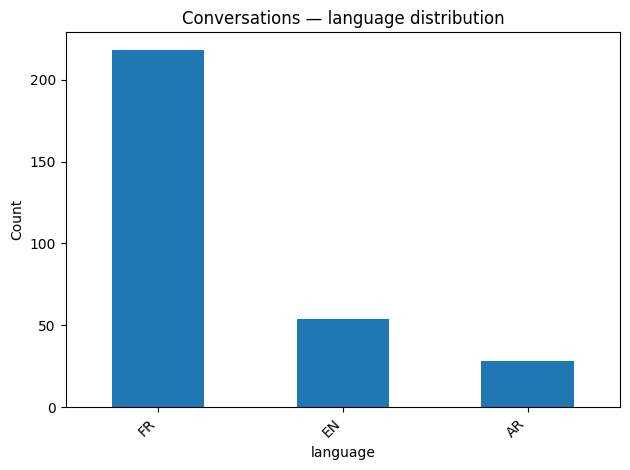

In [ ]:
plot_bar(safe_value_counts(conv_df, "language"), "Conversations — language distribution", xlabel="language")

## 2.2 Objection Types
Objections are important to shape retrieval + response generation.

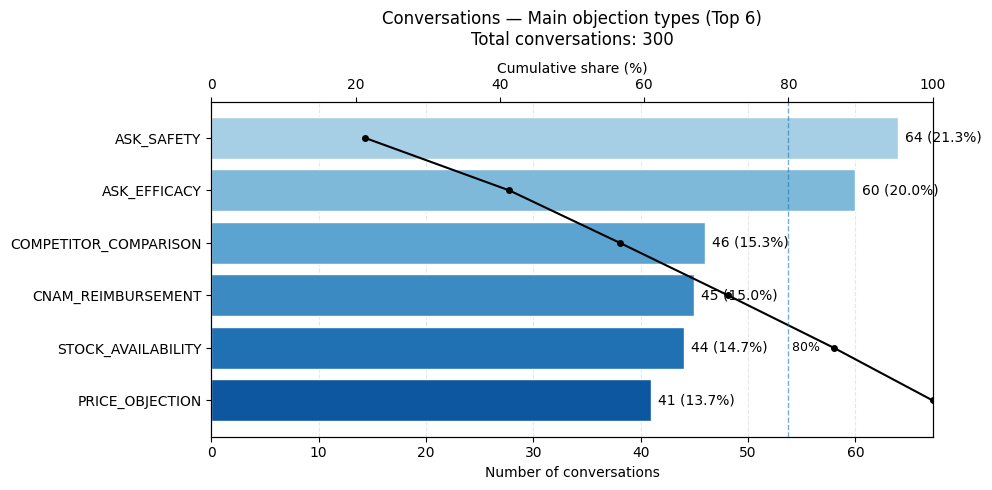

Top-3 objection types cover: 56.7% of conversations.


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- Advanced Objection Plot (Counts + % + Pareto cumulative) ---
vc = safe_value_counts(conv_df, "main_objection_type", topn=20)

# Ensure sorted descending
vc = vc.sort_values(ascending=False)

labels = vc.index.astype(str).tolist()
counts = vc.values.astype(int)
total = int(vc.sum())
perc = counts / total * 100
cum_perc = np.cumsum(perc)

fig, ax = plt.subplots(figsize=(10, 5))

# Bars (horizontal)
y = np.arange(len(labels))
colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(labels)))
bars = ax.barh(y, counts, color=colors, edgecolor="white", linewidth=1)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()

# Labels on bars: "count (xx.x%)"
for i, (c, p) in enumerate(zip(counts, perc)):
    ax.text(c + max(counts)*0.01, i, f"{c} ({p:.1f}%)", va="center", fontsize=10)

# Ax formatting
ax.set_xlabel("Number of conversations")
ax.set_title(f"Conversations — Main objection types (Top {len(labels)})\nTotal conversations: {total}", pad=12)

# Light grid
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Pareto cumulative line (secondary axis)
ax2 = ax.twiny()
ax2.plot(cum_perc, y, color="black", marker="o", linewidth=1.5, markersize=4)
ax2.set_xlim(0, 100)
ax2.set_xlabel("Cumulative share (%)")

# Annotate key Pareto thresholds (80%)
try:
    idx80 = int(np.where(cum_perc >= 80)[0][0])
    ax2.axvline(80, linestyle="--", linewidth=1, alpha=0.6)
    ax2.text(80, idx80, " 80%", va="center", fontsize=9)
except Exception:
    pass

plt.tight_layout()
plt.show()

# Extra insight (quick text output)
top3_share = perc[:3].sum()
print(f"Top-3 objection types cover: {top3_share:.1f}% of conversations.")

## 2.3 Doctor Specialty & Persona
We inspect how diverse the simulated/collected interactions are.

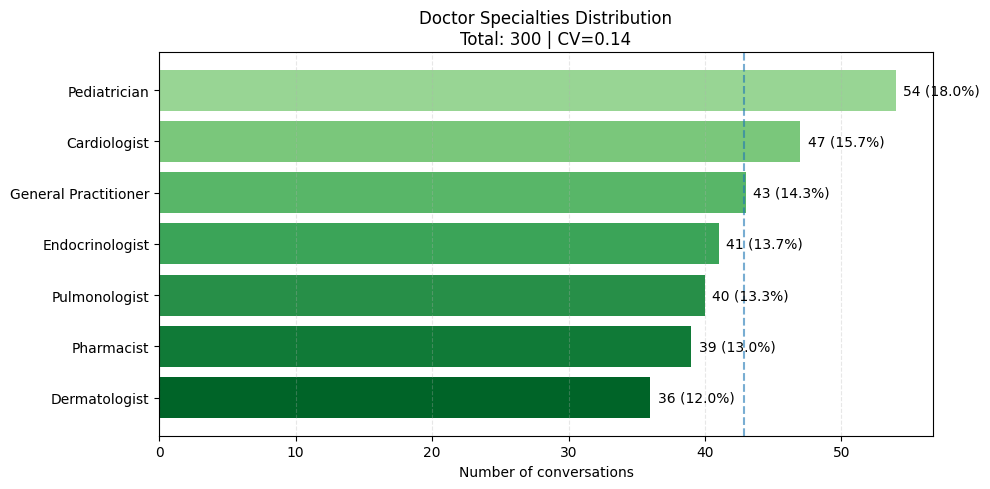

Mean conversations per specialty: 42.9
Coefficient of variation: 0.14


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Advanced Doctor Specialty Visualization -----

vc = safe_value_counts(conv_df, "doctor_specialty", topn=20)
vc = vc.sort_values(ascending=False)

labels = vc.index.astype(str)
counts = vc.values
total = counts.sum()
perc = counts / total * 100

mean_val = counts.mean()
std_val = counts.std()
cv = std_val / mean_val  # coefficient of variation

fig, ax = plt.subplots(figsize=(10,5))

colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(labels)))
bars = ax.barh(labels, counts, color=colors)

ax.invert_yaxis()

# Add labels
for i, (c,p) in enumerate(zip(counts, perc)):
    ax.text(c + max(counts)*0.01, i, f"{c} ({p:.1f}%)", va="center")

# Mean line
ax.axvline(mean_val, linestyle="--", alpha=0.6)
ax.set_title(f"Doctor Specialties Distribution\nTotal: {total} | CV={cv:.2f}")
ax.set_xlabel("Number of conversations")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean conversations per specialty: {mean_val:.1f}")
print(f"Coefficient of variation: {cv:.2f}")

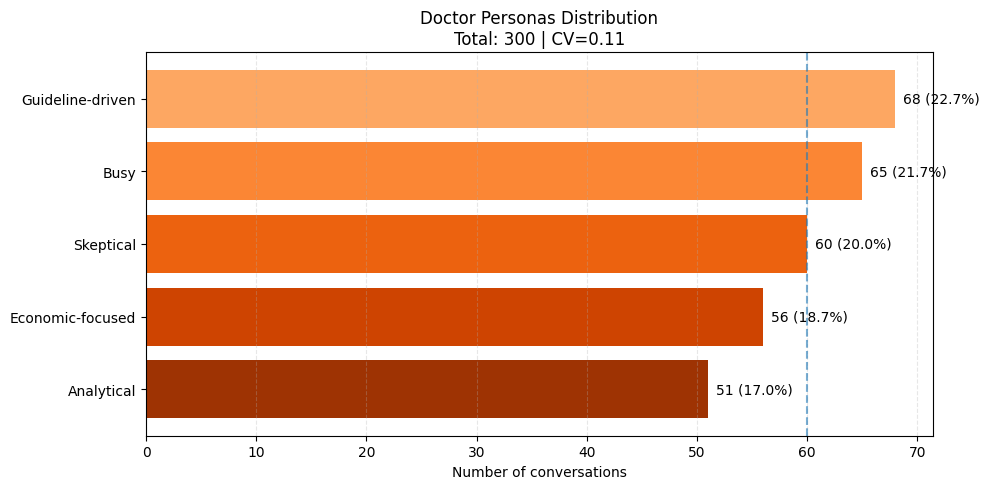

Mean conversations per persona: 60.0
Coefficient of variation: 0.11


In [31]:
# ----- Advanced Doctor Persona Visualization -----

vc = safe_value_counts(conv_df, "doctor_persona", topn=20)
vc = vc.sort_values(ascending=False)

labels = vc.index.astype(str)
counts = vc.values
total = counts.sum()
perc = counts / total * 100

mean_val = counts.mean()
std_val = counts.std()
cv = std_val / mean_val

fig, ax = plt.subplots(figsize=(10,5))

colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(labels)))
bars = ax.barh(labels, counts, color=colors)

ax.invert_yaxis()

for i, (c,p) in enumerate(zip(counts, perc)):
    ax.text(c + max(counts)*0.01, i, f"{c} ({p:.1f}%)", va="center")

ax.axvline(mean_val, linestyle="--", alpha=0.6)
ax.set_title(f"Doctor Personas Distribution\nTotal: {total} | CV={cv:.2f}")
ax.set_xlabel("Number of conversations")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean conversations per persona: {mean_val:.1f}")
print(f"Coefficient of variation: {cv:.2f}")

###🔥 Cross Analysis : Specialty × Persona

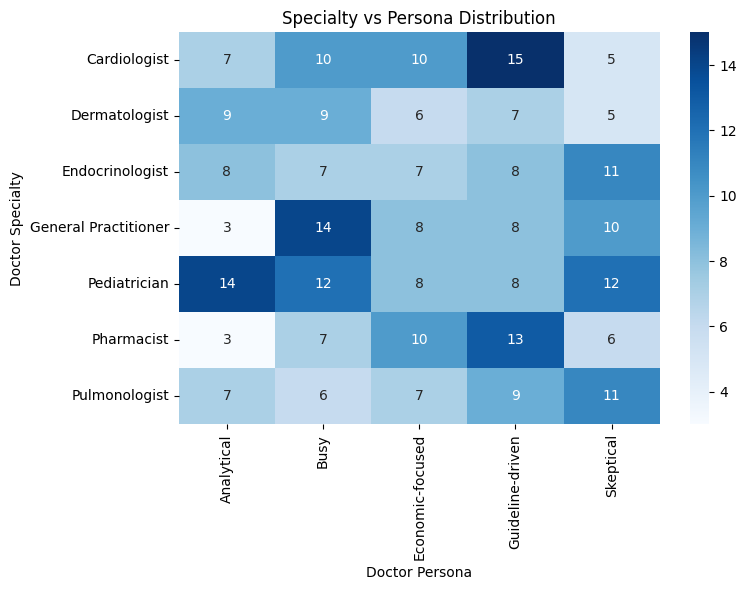

In [32]:
import seaborn as sns

pivot = pd.crosstab(conv_df["doctor_specialty"],
                    conv_df["doctor_persona"])

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="Blues", fmt="d")
plt.title("Specialty vs Persona Distribution")
plt.ylabel("Doctor Specialty")
plt.xlabel("Doctor Persona")
plt.tight_layout()
plt.show()

## 2.4 Score Distributions (Sentiment / Engagement / Interest)
We check distributions and potential outliers.

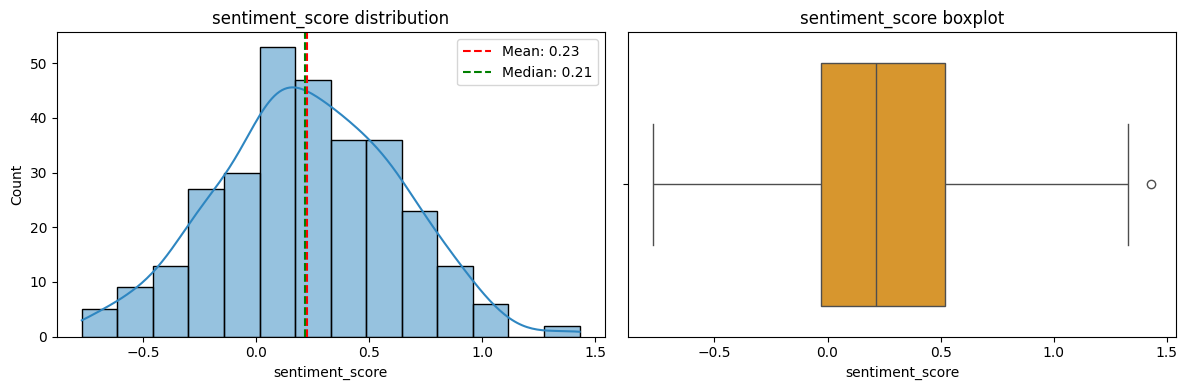

--- SENTIMENT_SCORE ---
Mean: 0.23
Median: 0.21
Std: 0.39
Skewness: -0.00
Kurtosis: -0.17
Shapiro p-value: 0.8590
→ Distribution close to normal




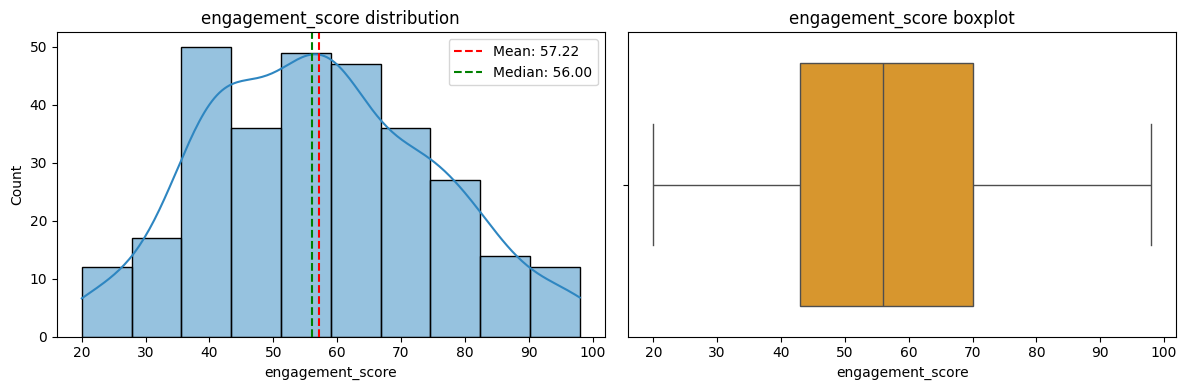

--- ENGAGEMENT_SCORE ---
Mean: 57.22
Median: 56.00
Std: 17.72
Skewness: 0.21
Kurtosis: -0.48
Shapiro p-value: 0.0076
→ Distribution NOT normal




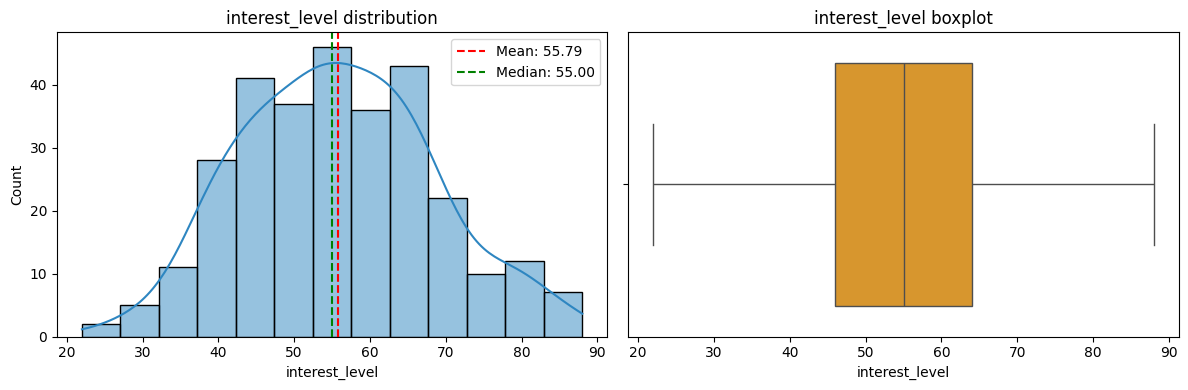

--- INTEREST_LEVEL ---
Mean: 55.79
Median: 55.00
Std: 12.69
Skewness: 0.18
Kurtosis: -0.29
Shapiro p-value: 0.1500
→ Distribution close to normal




In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def advanced_score_analysis(df, col):

    data = df[col].dropna()

    mean = data.mean()
    median = data.median()
    std = data.std()
    skew = data.skew()
    kurt = data.kurtosis()

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Histogram + KDE
    sns.histplot(data, kde=True, ax=axes[0], color="#2E86C1")
    axes[0].axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.2f}")
    axes[0].axvline(median, color="green", linestyle="--", label=f"Median: {median:.2f}")
    axes[0].set_title(f"{col} distribution")
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=data, ax=axes[1], color="#F39C12")
    axes[1].set_title(f"{col} boxplot")

    plt.tight_layout()
    plt.show()

    print(f"--- {col.upper()} ---")
    print(f"Mean: {mean:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Std: {std:.2f}")
    print(f"Skewness: {skew:.2f}")
    print(f"Kurtosis: {kurt:.2f}")

    # Normality test (Shapiro)
    if len(data) < 5000:  # Shapiro works better small-mid datasets
        stat, p = stats.shapiro(data)
        print(f"Shapiro p-value: {p:.4f}")
        if p > 0.05:
            print("→ Distribution close to normal")
        else:
            print("→ Distribution NOT normal")
    print("\n")

for col in ["sentiment_score", "engagement_score", "interest_level"]:
    if col in conv_df.columns:
        advanced_score_analysis(conv_df, col)

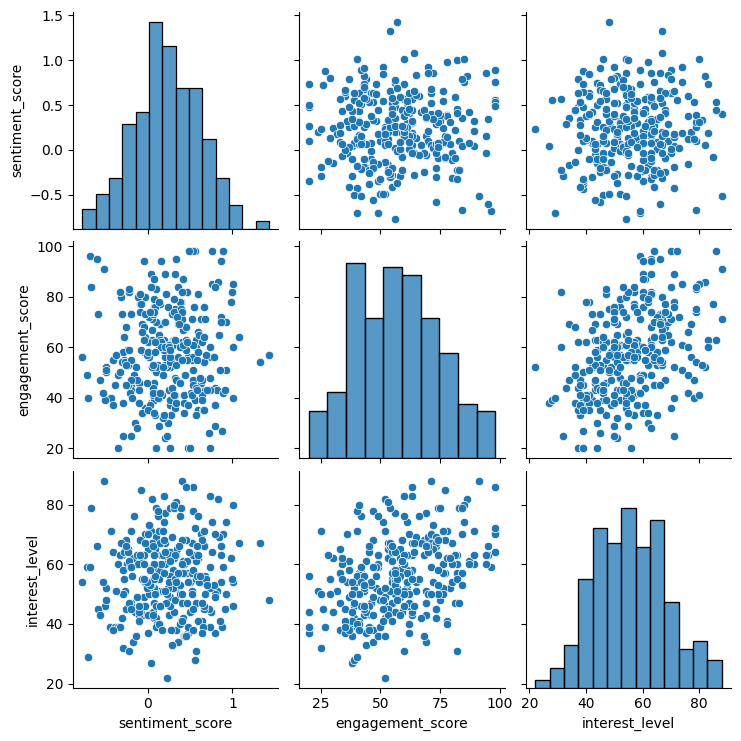

                  sentiment_score  engagement_score  interest_level
sentiment_score          1.000000          0.039743         0.06708
engagement_score         0.039743          1.000000         0.39243
interest_level           0.067080          0.392430         1.00000


In [34]:
sns.pairplot(conv_df[["sentiment_score","engagement_score","interest_level"]])
plt.show()

print(conv_df[["sentiment_score","engagement_score","interest_level"]].corr())

### Score Distributions & Correlation Analysis

The three behavioral metrics show coherent and realistic patterns.

**Sentiment Score**
- Slightly positive on average (mean ≈ 0.23)
- Approximately normally distributed
- Very weak correlation with engagement (0.04) and interest (0.07)

This suggests emotional tone does not strongly influence commercial outcomes.

**Engagement Score**
- Mean ≈ 57 with high variability
- Non-normal distribution
- Moderately correlated with interest (r ≈ 0.39)

Higher engagement tends to increase product interest.

**Interest Level**
- Mean ≈ 55.8
- Approximately normal distribution
- Positively influenced by engagement

### Overall Insight

The dataset shows behavioral realism:
- Engagement drives interest
- Sentiment has limited impact
- No artificial or perfect correlations

These properties support the dataset’s suitability for modeling medical interaction dynamics in a RAG-based system.

## 2.5 Relationships Between Scores
Simple scatter plots:
- sentiment vs interest
- engagement vs interest

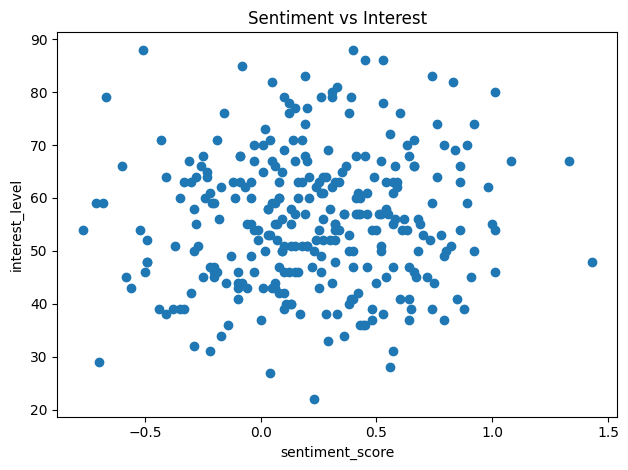

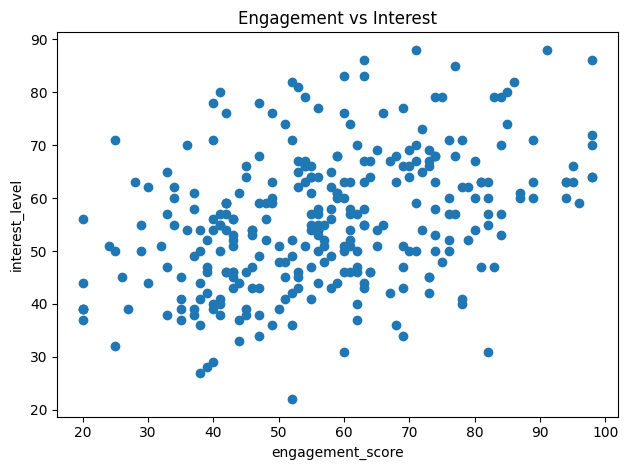

In [ ]:
if set(["sentiment_score", "interest_level"]).issubset(conv_df.columns):
    plot_scatter(conv_df["sentiment_score"], conv_df["interest_level"],
                 "Sentiment vs Interest", "sentiment_score", "interest_level")

if set(["engagement_score", "interest_level"]).issubset(conv_df.columns):
    plot_scatter(conv_df["engagement_score"], conv_df["interest_level"],
                 "Engagement vs Interest", "engagement_score", "interest_level")

### Relationships Between Scores

**Sentiment vs Interest**  
No clear linear pattern. The correlation is very weak (r ≈ 0.07), meaning emotional tone has little impact on product interest.

**Engagement vs Interest**  
Clear positive trend. The moderate correlation (r ≈ 0.39) shows that higher engagement tends to increase interest.

### Key Insight

Interest is mainly driven by engagement, not sentiment.  
This reflects realistic medical decision-making behavior.

## 2.6 Transcript Length & Number of Turns
We compute:
- transcript character length
- number of dialogue turns from `turns_json` (if present)

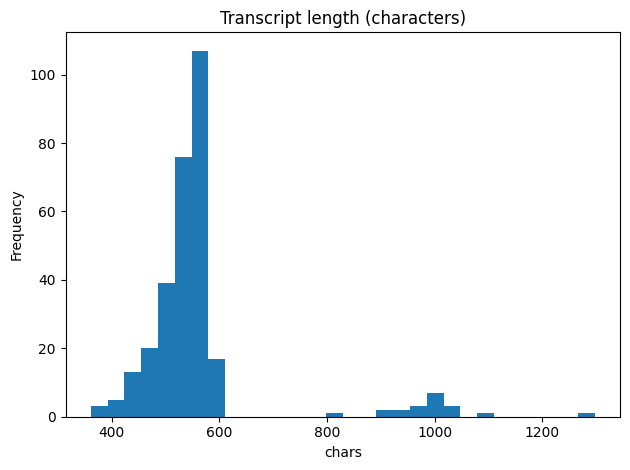

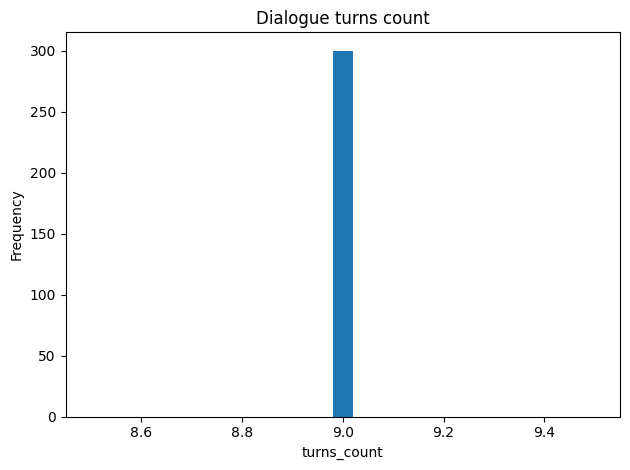

In [ ]:
# Transcript length
if "transcript" in conv_df.columns:
    conv_df["transcript_len"] = conv_df["transcript"].astype("string").fillna("").str.len()
    plot_hist(conv_df["transcript_len"], "Transcript length (characters)", xlabel="chars")

# Turns count
def parse_turns_count(x):
    try:
        if pd.isna(x):
            return np.nan
        if isinstance(x, list):
            return len(x)
        # often stored as a JSON string
        obj = json.loads(x) if isinstance(x, str) else x
        return len(obj) if isinstance(obj, list) else np.nan
    except Exception:
        return np.nan

if "turns_json" in conv_df.columns:
    conv_df["turns_count"] = conv_df["turns_json"].apply(parse_turns_count)
    plot_hist(conv_df["turns_count"], "Dialogue turns count", xlabel="turns_count", bins=25)

##Heatmap : Specialty × Interest

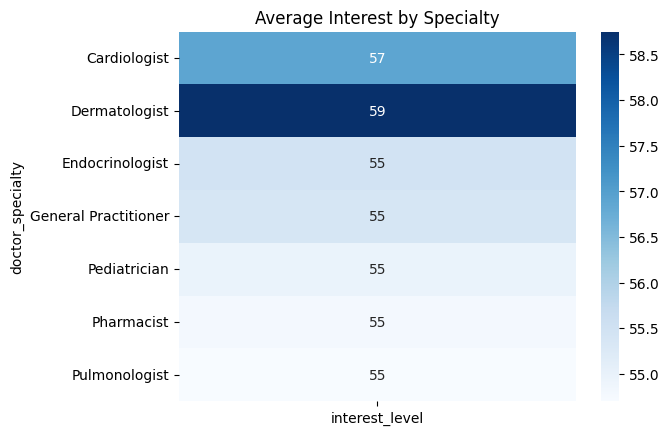

In [39]:
pivot = conv_df.pivot_table(
    values="interest_level",
    index="doctor_specialty",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="Blues")
plt.title("Average Interest by Specialty")
plt.show()

##Timeline Evolution (Date vs Interest)

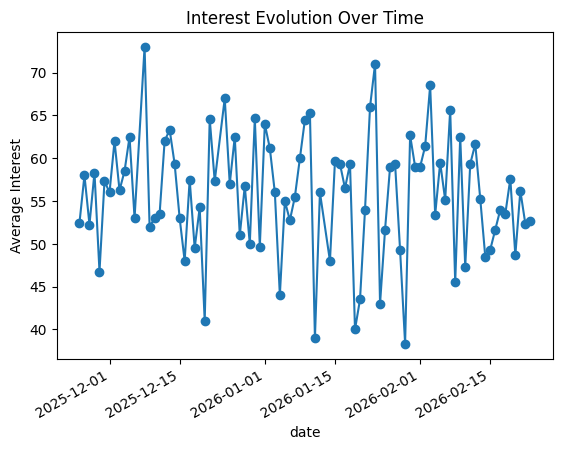

In [41]:
conv_df["date"] = pd.to_datetime(conv_df["date"])
daily_interest = conv_df.groupby("date")["interest_level"].mean()

daily_interest.plot(marker="o")
plt.title("Interest Evolution Over Time")
plt.ylabel("Average Interest")
plt.show()

##Objection vs Interest Heatmap (Strategic View)

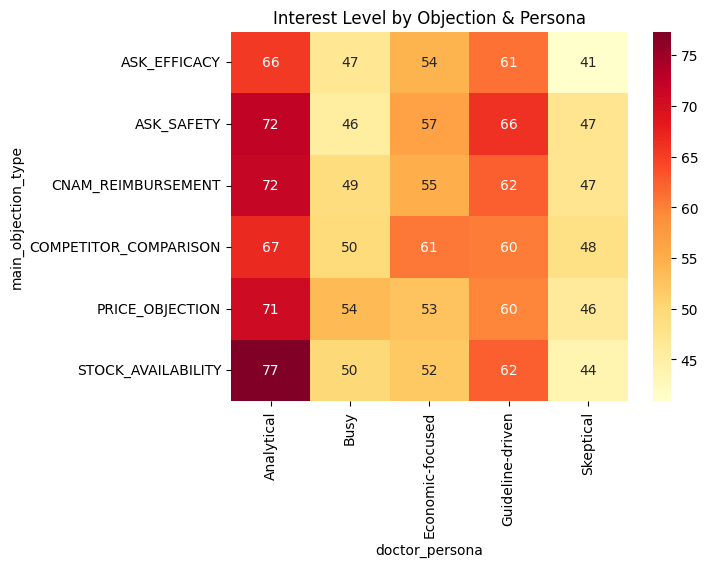

In [44]:
pivot = conv_df.pivot_table(
    values="interest_level",
    index="main_objection_type",
    columns="doctor_persona",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="YlOrRd")
plt.title("Interest Level by Objection & Persona")
plt.show()

##Commercial Funnel Simulation

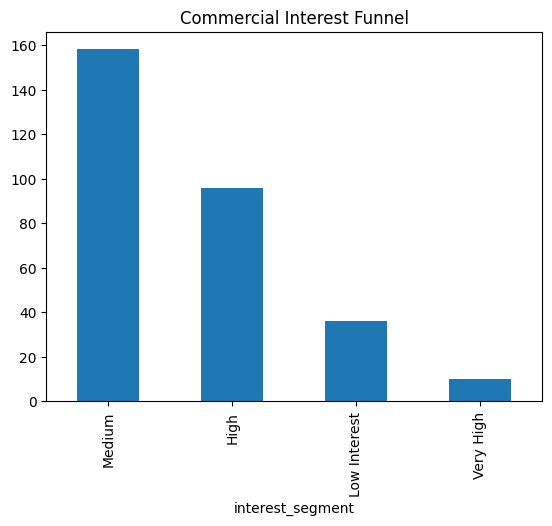

In [45]:
bins = [0,40,60,80,100]
labels = ["Low Interest","Medium","High","Very High"]

conv_df["interest_segment"] = pd.cut(
    conv_df["interest_level"], bins=bins, labels=labels
)

conv_df["interest_segment"].value_counts().plot(kind="bar")
plt.title("Commercial Interest Funnel")
plt.show()

##Geographic Commercial Performance

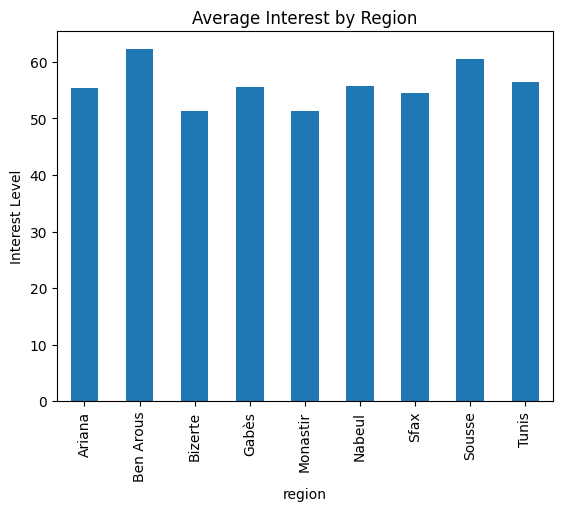

In [46]:
region_perf = conv_df.groupby("region")["interest_level"].mean()

region_perf.plot(kind="bar")
plt.title("Average Interest by Region")
plt.ylabel("Interest Level")
plt.show()

## 2.7 Data Quality Snapshot (Conversations)
Missingness helps decide cleaning requirements before indexing for RAG.

In [48]:
missingness_bar(conv_df, "Conversations — Missingness (%)", topn=40)

[Skip] Nothing to plot for: Conversations — Missingness (%)


# 3) Vital Product Knowledge (Derived Table)
For BO2/DSO2 (RAG), we need a **product knowledge base** with:
- product_name
- product_category
- product_description

Even if you store product knowledge separately later, we can already **derive** a product table from the conversation dataset and visualize:
- number of unique products
- top categories
- description length distribution

In [ ]:
product_cols = [c for c in ["product_name", "product_category", "product_description"] if c in conv_df.columns]
if len(product_cols) == 0:
    print("No product fields found in conversation dataset.")
else:
    prod_kb = conv_df[product_cols].copy()
    for c in product_cols:
        prod_kb[c] = prod_kb[c].astype("string").replace({"nan": np.nan})
    prod_kb = prod_kb.dropna(subset=["product_name"]) if "product_name" in prod_kb.columns else prod_kb
    prod_kb = prod_kb.drop_duplicates(subset=["product_name"]) if "product_name" in prod_kb.columns else prod_kb.drop_duplicates()

    display(prod_kb.head(10))
    print("Unique products:", prod_kb["product_name"].nunique() if "product_name" in prod_kb.columns else len(prod_kb))

,product_name,product_category,product_description
0,Vitonic Zinc Vit.D3 30 Gélules,Compléments Alimentaires | Confort | Zinc,"Vitonic Zinc Vit.D3 est un complément alimentaire qui contribuer au fonctionnement normal du système nerveux reproductif , booster le système immunita"
1,Pédiakids Creme Pour Le Change 40 Gr,Bébé et Maman | Change de bébé | Crème de change,Pédiakids Crème pour le change est une formule spécialement élaborée pour le change de bébé dès la naissance et adaptée à l épiderme fessier et aux ag
2,Vital Phytoveine Gel 90 Gr,Corps | Jambes lourdes,"VITAL PHYTOVEINE Gel, 90 gr pour les Jambes lourdes et aider le retour du sang veineux. | Soulage les douleurs des jambes lourdes | Stimule la circula"
3,Phytothera Levure De Riz Rouge 60 Gélules,Compléments Alimentaires | Minceur | Brule graisse,"LEVURE DE RIZ ROUGE est un complément alimentaire qui baisse le cholestérol, fait diminuer les taux des triglycérides, maintient une protection cardio"
4,Phytothera Maca Gel B/60,Compléments Alimentaires | Fertilité | Fertilité homme,Ce complément alimentaire aide à dynamiser naturellement la puissance sexuelle et à stimuler le désir tout en soutenant la performance physique et l’e
5,Vital Fersang Junior Sirop 150ml,Compléments Alimentaires | Compléments alimentaires enfant,Fersang est un complément alimentaire formulé pour soutenir la formation des globules rouges et prévenir ou corriger les carences en fer et en vitamin
6,Vitonic Tonus 30 Gélules,Compléments Alimentaires | Santé | Immunité,VITONIC TONUS est un complément alimentaire qui est conseillé pour surmonter les périodes de stress et de surmenage et pallier les carences. Ce produi
7,Pédiakids Multi Vitamines Pomme 150 ml,Compléments Alimentaires | Compléments alimentaires enfant,Pédiakids multivitamines pomme : favorise les apports essentiels en vitamines et minéraux chez les jeunes enfants pour garantir une croissance équilib
8,Plantherapie Planthiol Sirop 150 ml,Compléments Alimentaires | Santé | Gorge et respiratoire,Planthérapie Planthiol est une formule unique pour adoucir les voies respiratoires et calmer la toux grasse. | Diminue la toux grasse | Expectorant po
9,Phytothera Pectine De Pomme 30 Gélules,Compléments Alimentaires | Minceur | Coupe faim,PHYTOTHERA Pectine de Pomme est un complément alimentaire conseillé pour : | Modérer l’appétit. | Procurer un confort intestinal. | Prévenir la consti


Unique products: 181


/tmp/ipython-input-2419095215.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


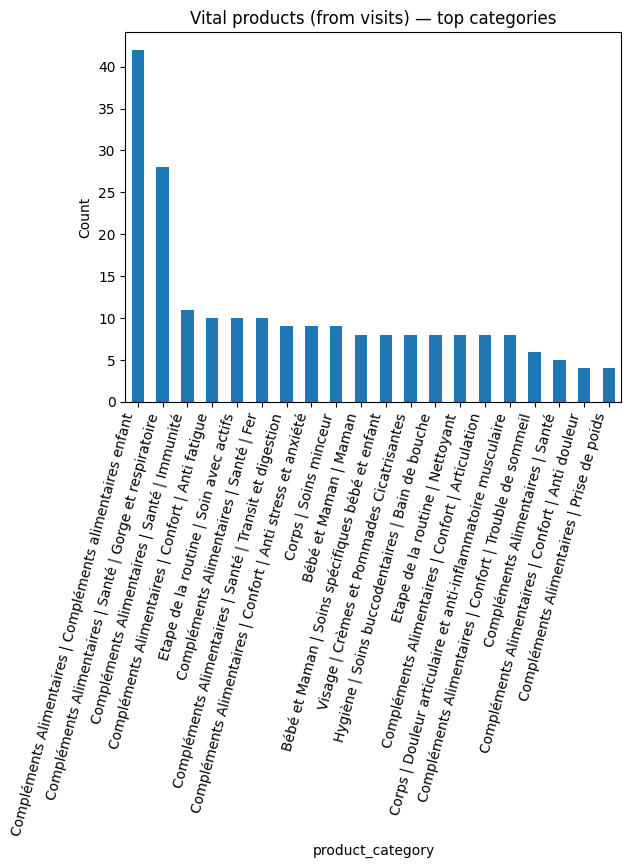

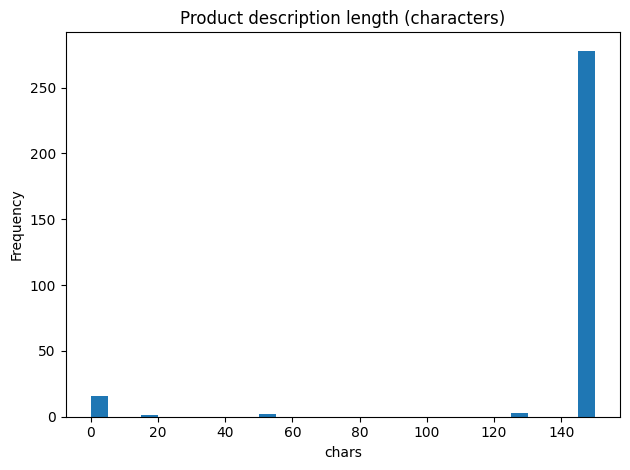

In [ ]:
# Top product categories
if "product_category" in conv_df.columns:
    plot_bar(safe_value_counts(conv_df, "product_category", topn=20),
             "Vital products (from visits) — top categories", xlabel="product_category", rotate=75)

# Description length distribution
if "product_description" in conv_df.columns:
    desc_len = conv_df["product_description"].astype("string").fillna("").str.len()
    plot_hist(desc_len, "Product description length (characters)", xlabel="chars")

## 3.1 RAG Readiness Checks (Product KB)
We quickly check:
- missing descriptions
- duplicate product names
- extremely short descriptions

In [ ]:
if "product_name" in conv_df.columns:
    missing_desc = None
    if "product_description" in conv_df.columns:
        missing_desc = conv_df["product_description"].isna().mean() * 100
        print(f"Missing product_description: {missing_desc:.2f}%")

    dup_rate = 1 - (conv_df["product_name"].nunique() / len(conv_df))
    print(f"Duplicate rate by product_name (higher means repeated promotions): {dup_rate:.2f}")

    if "product_description" in conv_df.columns:
        short_desc_pct = (conv_df["product_description"].astype('string').fillna('').str.len() < 40).mean() * 100
        print(f"Very short descriptions (<40 chars): {short_desc_pct:.2f}%")

Missing product_description: 0.00%
Duplicate rate by product_name (higher means repeated promotions): 0.40
Very short descriptions (<40 chars): 5.67%


# 4) FDA Large Dataset (`fda_large_dataset.csv`)
This dataset supports **compliance** and can be used as:
- a retrieval source for regulatory/safety statements
- a validation layer (grounding / citations)
- a filter for claims (avoid hallucinations)

Because FDA datasets vary widely by schema, we:
1. Load the CSV
2. Inspect columns & missingness
3. Auto-detect candidate categorical/text columns
4. Visualize key distributions

In [8]:
fda_df = pd.read_csv(FDA_PATH, low_memory=False)
print("FDA shape:", fda_df.shape)
display(fda_df.head(5))
display(pd.DataFrame({"column": fda_df.columns, "dtype": fda_df.dtypes.astype(str)}).head(30))

FDA shape: (5000, 4)


,drug_name,active_ingredient,dosage,side_effects
0,SILICEA,ACTIVE INGREDIENT SILICEA HPUS 2X and higher,"DOSAGE Adults- Take 4 or 6 Pellets by mouth, three times daily or as suggested by physician. Children 2 years and older- take 1/2 the adult dose.",NaN
1,NaN,"BRONZE ACTIVE INGREDIENTS: TITANIUM DIOXIDE 2 %, ETHYLHEXYL METHOXYCINNAMATE 7%, ZINC OXIDE 24.5%",Directions Protection Naturelle SPF 46 PA+++ Powder can be used on clean skin or over makeup. Shake lightly to activate the flow of powder. Sweep the brush all over the face to evenly distribute p...,NaN
2,Betadine,"Drug Facts Active ingredients Povidone-iodine, 5% (0.5% available iodine)","Directions clean the affected area spray a small amount of the product on the area 1 to 3 times daily may be covered with a sterile bandage if bandaged, let dry first",NaN
3,NaN,ACTIVE INGREDIENTS MEZEREUM,DIRECTIONS Adults: Dissolve 3 to 5 under the tongue three times a day or as directed by Lic. Practitioner. Take at greater intervals as condition subsides. Children: Dissolve 3 to 5 under the tong...,NaN
4,NaN,NaN,DOSAGE AND ADMINISTRATION The recommended dosage regimen for the treatment of bacterial conjunctivitis is: Days 1 and 2 Instill one to two drops every two to four hours in the affected eye(s). Day...,"ADVERSE REACTIONS Ophthalmic use: The most frequently reported drug-related adverse reaction was transient ocular burning or discomfort. Other reported reactions include stinging, redness, itching..."


,column,dtype
drug_name,drug_name,object
active_ingredient,active_ingredient,object
dosage,dosage,object
side_effects,side_effects,object


## 4.1 Missingness Overview (FDA)
Large reference datasets often have sparse columns. We visualize top missing columns.

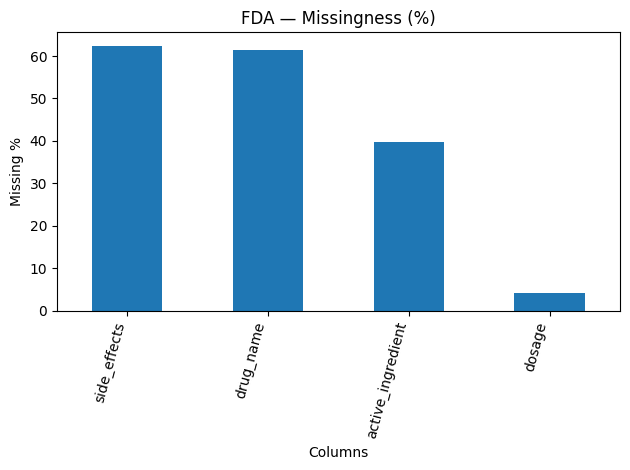

In [9]:
missingness_bar(fda_df, "FDA — Missingness (%)", topn=40)

## 4.2 Candidate Categorical Columns (Top Values)
We automatically pick columns with relatively low cardinality (useful for bar charts).

In [10]:
# Identify candidate categorical columns (heuristic)
cat_candidates = []
for c in fda_df.columns:
    if fda_df[c].dtype == "object" or str(fda_df[c].dtype).startswith("string"):
        nunique = fda_df[c].nunique(dropna=True)
        if 2 <= nunique <= 30:
            cat_candidates.append((c, nunique))

cat_candidates = sorted(cat_candidates, key=lambda x: x[1])
cat_candidates[:15], len(cat_candidates)

([], 0)

In [11]:
# Plot top values for the first few categorical candidates
for c, nunique in cat_candidates[:6]:
    vc = fda_df[c].astype("string").fillna("NA").value_counts().head(15)
    plot_bar(vc, f"FDA — {c} (top values)", xlabel=c, rotate=75)

## 4.3 Candidate Text Columns (Length Distribution)
We detect possible text columns (large average string length) and plot length histograms.

In [12]:
text_candidates = []
for c in fda_df.columns:
    if fda_df[c].dtype == "object" or str(fda_df[c].dtype).startswith("string"):
        s = fda_df[c].astype("string")
        # skip if almost empty
        non_na = s.notna().mean()
        if non_na < 0.05:
            continue
        avg_len = s.dropna().str.len().mean()
        if avg_len and avg_len > 60:
            text_candidates.append((c, avg_len, non_na))

text_candidates = sorted(text_candidates, key=lambda x: x[1], reverse=True)
text_candidates[:10]

[('side_effects', np.float64(5855.403835908364), np.float64(0.3754)),
 ('dosage', np.float64(1659.6466290962221), np.float64(0.9582)),
 ('active_ingredient', np.float64(98.38270377733599), np.float64(0.6036))]

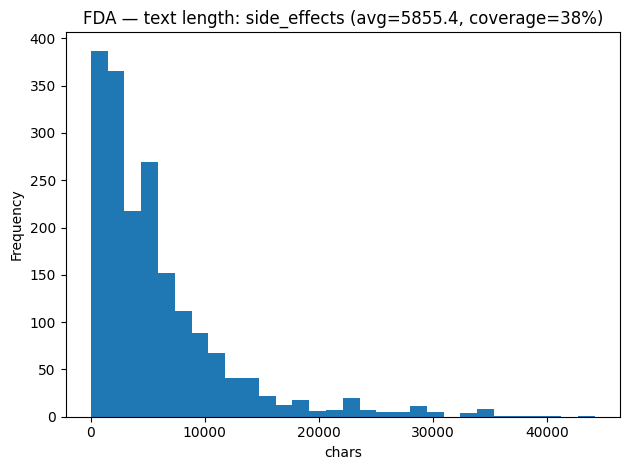

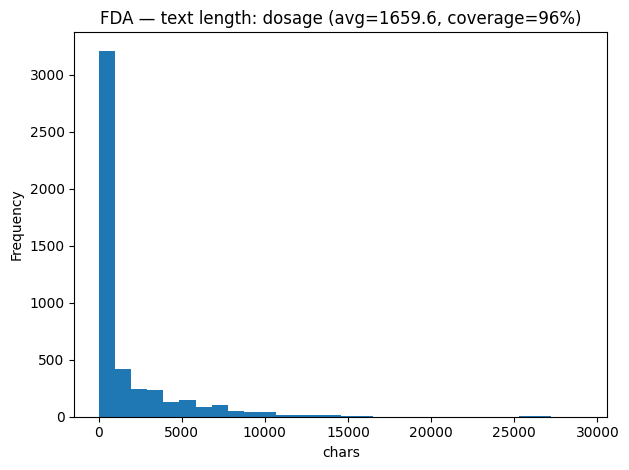

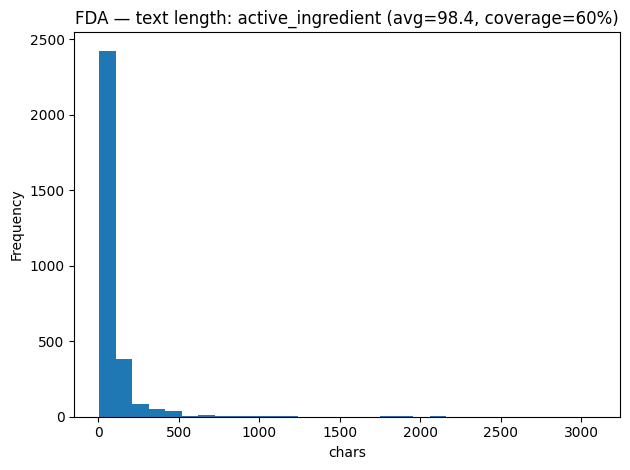

In [13]:
for c, avg_len, non_na in text_candidates[:4]:
    lens = fda_df[c].astype("string").dropna().str.len()
    plot_hist(lens, f"FDA — text length: {c} (avg={avg_len:.1f}, coverage={non_na:.0%})", xlabel="chars", bins=30)

## 4.4 Quick Check: Duplicates & Basic Quality
This helps for indexing (RAG) and deduplication.

In [14]:
print("Duplicate rows:", fda_df.duplicated().sum())

# If there is an obvious ID-like column, check uniqueness (heuristic)
id_like = [c for c in fda_df.columns if any(k in c.lower() for k in ["id", "application", "ndc", "product", "drug"])]

print("ID-like columns (heuristic):", id_like[:15])
for c in id_like[:3]:
    try:
        nunique = fda_df[c].nunique(dropna=True)
        print(f"{c}: nunique={nunique} / rows={len(fda_df)}")
    except Exception as e:
        print("Skip", c, "->", e)

Duplicate rows: 390
ID-like columns (heuristic): ['drug_name', 'side_effects']
drug_name: nunique=1530 / rows=5000
side_effects: nunique=1743 / rows=5000


# 5) Summary & Next Steps (for BO2/DSO2)

### What we verified in this phase
- **CRM dataset**: entity structure + key distributions (users/products/visits).
- **Conversation dataset**: multilingual coverage, objection types, persona/specialty diversity, score behavior, transcript/turn characteristics.
- **Vital product knowledge**: extracted a product KB (name/category/description) and checked RAG readiness.
- **FDA dataset**: explored schema, missingness, and candidate columns for compliance retrieval.

### Next steps (after Data Understanding)
1. **Data cleaning**: normalize languages, fix missing values, parse JSON fields, remove duplicates.
2. **RAG indexing plan**:
   - Index product KB as primary medical/product facts.
   - Index FDA dataset as compliance/reference layer.
3. **Evaluation plan**: define tests for correctness, multilingual quality, and compliance (citations / refusal rules).